# Distribution of OM segments

In [1]:

import geopandas as gpd
import pandas as pd

files = {
    "Hamar": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\om_segments.geojson",
    "Moss": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\om_segments.geojson",
    "Gudbrandsdalen": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\om_segments.geojson",
}

dfs = []

for area, path in files.items():
    gdf = gpd.read_file(path)
    gdf["Area"] = area
    print(f"Read {len(gdf)} rows from {area} ({path})") 
    dfs.append(gdf)

# Concatenate all into one GeoDataFrame
gdf_allSegements = pd.concat(dfs, ignore_index=True)

# Remove one specific segment by its ID
segment_to_remove = '84d1aa20-dcff-425f-911a-fa90c2dd71b2'  # Replace with the actual segment ID to remove
gdf_allSegements = gdf_allSegements[gdf_allSegements['id'] != segment_to_remove]




Read 3844 rows from Hamar (C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\om_segments.geojson)
Read 3994 rows from Moss (C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\om_segments.geojson)
Read 1395 rows from Gudbrandsdalen (C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\om_segments.geojson)


<Figure size 1200x600 with 0 Axes>

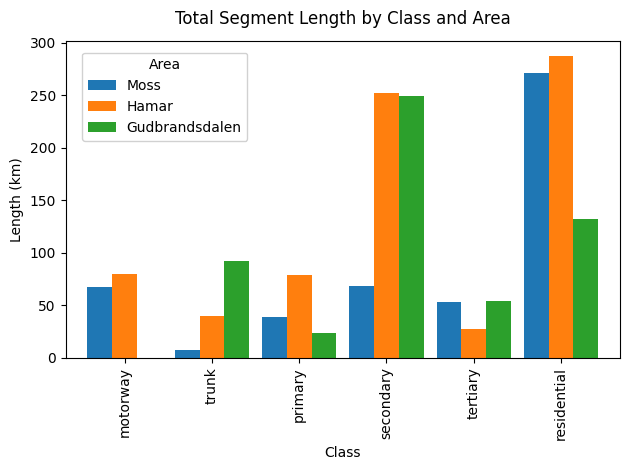

In [2]:

import matplotlib.pyplot as plt
import pandas as pd

# Desired display order
class_order = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential']
area_order  = ['Moss', 'Hamar', 'Gudbrandsdalen']

# Project to EPSG:5973 for accurate metric lengths
gdf_lenSegments = gdf_allSegements.to_crs(epsg=5973).copy()

# Compute length in kilometers
gdf_lenSegments["length_km"] = gdf_lenSegments.geometry.length / 1000.0
gdf_lenSegments["length"] = gdf_lenSegments.geometry.length # in meters 

# Aggregate by class and Area (class on rows for x-axis)
agg = (
    gdf_lenSegments.groupby(["class", "Area"], dropna=False)["length_km"]
    .sum()
    .reset_index()
)

# Pivot: Classes (rows/x-axis) x Areas (columns/grouped bars)
pivot = agg.pivot(index="class", columns="Area", values="length_km").fillna(0)

# Enforce desired ordering
existing_classes = [c for c in class_order if c in pivot.index]
extra_classes = [c for c in pivot.index if c not in class_order]
pivot = pivot.reindex(index=existing_classes + extra_classes)

existing_areas = [a for a in area_order if a in pivot.columns]
extra_areas = [a for a in pivot.columns if a not in area_order]
pivot = pivot.reindex(columns=existing_areas + extra_areas)

# Plot grouped bar chart: class on x-axis, grouped by area
plt.figure(figsize=(12, 6))
ax = pivot.plot(kind="bar", width=0.85)

ax.set_title("Total Segment Length by Class and Area", pad=12)
ax.set_xlabel("Class")
ax.set_ylabel("Length (km)")

# ✅ Legend inside the axes, upper-left
# Option A (simple): just loc='upper left'
# ax.legend(title="Area", loc="upper left")

# Option B (fine-tuned): slight offset from the corner to avoid overlapping the y-axis
ax.legend(
    title="Area",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),  # x, y in axes fraction coordinates
    frameon=True,
    framealpha=0.9,
    borderaxespad=0.4
)

plt.tight_layout()
plt.show()


# Network matching

In [3]:
# Read all connector JSON files in the Data folder and merge them into a single GeoDataFrame.
import geopandas as gpd
import pandas as pd     

files = {
    "Hamar": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\om_connectors.geojson",
    "Moss": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\om_connectors.geojson",
    "Gudbrandsdalen": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\om_connectors.geojson",
}

dfs = []

for area, path in files.items():
    gdf = gpd.read_file(path)
    gdf["Area"] = area
    print(f"Read {len(gdf)} rows from {area} ({path})")
    dfs.append(gdf)

# Concatenate all into one GeoDataFrame
gdf_connectors = pd.concat(dfs, ignore_index=True)

Read 8493 rows from Hamar (C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\om_connectors.geojson)
Read 6787 rows from Moss (C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\om_connectors.geojson)
Read 3711 rows from Gudbrandsdalen (C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\om_connectors.geojson)


In [4]:

import pandas as pd
from pathlib import Path

# Paths to your files
files = {
    "Hamar": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\matched.xlsx",
    "Moss": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\matched.xlsx",
    "Gudbrandsdalen": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\matched.xlsx",
}

dfs = []

for area, path in files.items():
    # Read Sheet1 explicitly; use the openpyxl engine for .xlsx
    df = pd.read_excel(path, sheet_name="Sheet1", engine="openpyxl")
    # Insert area name as the first column
    df.insert(0, "Area", area)
    print(f"Read {len(df)} rows from {area} ({path})")
    dfs.append(df)


# Concatenate into one DataFrame (keeps columns aligned by name)
matching_df = pd.concat(dfs, ignore_index=True)




Read 18037 rows from Hamar (C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\matched.xlsx)
Read 15312 rows from Moss (C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\matched.xlsx)
Read 0 rows from Gudbrandsdalen (C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\matched.xlsx)


C:\Users\JETKNU\AppData\Local\Temp\ipykernel_33684\2700337889.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  matching_df = pd.concat(dfs, ignore_index=True)


In [5]:
# Read all harmonized segment JSON files in the Data folder and merge them into a single GeoDataFrame.
import geopandas as gpd
import pandas as pd     

files = {
    "Hamar": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\segments_lod.geojson",
    "Moss": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\segments_lod.geojson",
    "Gudbrandsdalen": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\segments_lod.geojson",
}

dfs = []

for area, path in files.items():
    gdf = gpd.read_file(path)
    gdf["Area"] = area
    print(f"Read {len(gdf)} rows from {area} ({path})")
    dfs.append(gdf)

# Concatenate all into one GeoDataFrame
gdf_matched_segments = pd.concat(dfs, ignore_index=True)

# Remove one specific segment by its ID
segment_to_remove = '84d1aa20-dcff-425f-911a-fa90c2dd71b2'  # Replace with the actual segment ID to remove      
gdf_matched_segments = gdf_matched_segments[gdf_matched_segments['segment_id'] != segment_to_remove]


Read 11683 rows from Hamar (C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\segments_lod.geojson)
Read 9110 rows from Moss (C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\segments_lod.geojson)
Read 4864 rows from Gudbrandsdalen (C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\segments_lod.geojson)


## Segment matching results

In [6]:
# Create a pivottable of length in meters per Area from each of gdf_lenSegments (Total OM segment length) and gdf_matched_segments (Diffbetween these = Unmatched length), and the proportion of matched length.
# Sort the result by Area: Moss, Hamar, Gudbrandsdalen.
# Add a row with totals at the bottom.
import pandas as pd
areas = area_order
pivot_total_length = gdf_lenSegments.groupby("Area")["length"].sum().reindex(areas)
pivot_matched_length = gdf_matched_segments.groupby("Area")["length"].sum().reindex(areas)
pivot_unmatched_length = pivot_total_length - pivot_matched_length  
pivot_proportion_matched = pivot_matched_length / pivot_total_length * 100.0

# Format meter values in the pivot table as integers
pivot_total_length = pivot_total_length.round(0).astype(int)
pivot_matched_length = pivot_matched_length.round(0).astype(int)    
pivot_unmatched_length = pivot_unmatched_length.round(0).astype(int)
# Format proportion as one decimal place.
pivot_proportion_matched = pivot_proportion_matched.round(1)


segment_summary_df = pd.DataFrame({
    "Total Length (m)": pivot_total_length,
    "Matched Length (m)": pivot_matched_length,
    "Unmatched Length (m)": pivot_unmatched_length,
    "Proportion Matched (%)": pivot_proportion_matched
})
segment_summary_df.loc["Total for all areas"] = segment_summary_df.sum(numeric_only=True)
segment_summary_df.at["Total for all areas", "Proportion Matched (%)"] = (
    segment_summary_df.at["Total for all areas", "Matched Length (m)"] / segment_summary_df.at["Total for all areas", "Total Length (m)"] * 100.0   
)

#drop the column "Matched Length (m)" from segment_summary_df   
segment_summary_df = segment_summary_df.drop(columns=["Matched Length (m)"])

segment_summary_df



,Total Length (m),Unmatched Length (m),Proportion Matched (%)
Area,,,
Moss,506071.0,6572.0,98.700000
Hamar,765586.0,5898.0,99.200000
Gudbrandsdalen,551426.0,2557.0,99.500000
Total for all areas,1823083.0,15027.0,99.175737


## Connector matching results 

In [7]:
# Read all connector JSON files in the Data folder and merge them into a single GeoDataFrame.
import geopandas as gpd
import pandas as pd     

files = {
    "Hamar": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\OM_UnmatchedConnectors.geojson",
    "Moss": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\OM_UnmatchedConnectors.geojson",
    "Gudbrandsdalen": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\OM_UnmatchedConnectors.geojson",
}

dfs = []

for area, path in files.items():
    gdf = gpd.read_file(path)
    gdf["Area"] = area
    print(f"Read {len(gdf)} rows from {area} ({path})")
    dfs.append(gdf)

# Concatenate all into one GeoDataFrame
gdf_unmatched_connectors = pd.concat(dfs, ignore_index=True)


Read 102 rows from Hamar (C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\OM_UnmatchedConnectors.geojson)
Read 177 rows from Moss (C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\OM_UnmatchedConnectors.geojson)
Read 90 rows from Gudbrandsdalen (C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\OM_UnmatchedConnectors.geojson)


In [8]:
# Create a pivottable of counts per Area from each of df_connectors (Total OM connectors) and gdf_unmatched_connectors (Unmatched connectors), and the proportion of nmatched connectors.
# Sort the result by Area: Moss, Hamar, Gudbrandsdalen.
# Add a row with totals at the bottom.


pivot_total = gdf_connectors.pivot_table(index="Area", values="geometry", aggfunc="count").rename(columns={"geometry": "Total Connectors"})
pivot_unmatched = gdf_unmatched_connectors.pivot_table(index="Area", values="geometry", aggfunc="count").rename(columns={"geometry": "Unmatched Connectors"})       
pivot_summary = pivot_total.join(pivot_unmatched, how="outer").fillna(0)
# Add totals row
totals = pivot_summary.sum(numeric_only=True)   
pivot_summary.loc["Total for all areas"] = totals

pivot_summary["Connector matching success(%)"] = ((pivot_summary["Total Connectors"] - pivot_summary["Unmatched Connectors"]) / pivot_summary["Total Connectors"]) * 100.0 
area_order = ['Moss', 'Hamar', 'Gudbrandsdalen','Total for all areas']
existing_areas = [a for a in area_order if a in pivot_summary.index]
extra_areas = [a for a in pivot_summary.index if a not in area_order]

# Reindex to desired order
connector_pivot_summary = pivot_summary.reindex(index=existing_areas + extra_areas)

connector_pivot_summary


,Total Connectors,Unmatched Connectors,Connector matching success(%)
Area,,,
Moss,6787,177,97.392073
Hamar,8493,102,98.799011
Gudbrandsdalen,3711,90,97.574778
Total for all areas,18991,369,98.056974


In [9]:
#Combine segment_summary_df and connector_pivot_summary into a single summary report.
summary_report = pd.concat([segment_summary_df, connector_pivot_summary], axis=1)

# show length values with 0 decimals, 1000 separator and a " m" suffix 
length_columns = ["Total Length (m)", "Unmatched Length (m)"]
for col in length_columns:
    summary_report[col] = summary_report[col].apply(lambda x: f"{x:,.0f} m") 

#Add 1000 separator to the "Total Connectors" and "Unmatched Connectors" columns
count_columns = ["Total Connectors", "Unmatched Connectors"]
for col in count_columns:
    summary_report[col] = summary_report[col].apply(lambda x: f"{x:,}")

# show % values with one decimal place and a "%" suffix    
percentage_columns = ["Proportion Matched (%)", "Connector matching success(%)"]
for col in percentage_columns:
    summary_report[col] = summary_report[col].apply(lambda x: f"{x:.1f} %")     
summary_report    

,Total Length (m),Unmatched Length (m),Proportion Matched (%),Total Connectors,Unmatched Connectors,Connector matching success(%)
Area,,,,,,
Moss,"506,071 m","6,572 m",98.7 %,"6,787",177,97.4 %
Hamar,"765,586 m","5,898 m",99.2 %,"8,493",102,98.8 %
Gudbrandsdalen,"551,426 m","2,557 m",99.5 %,"3,711",90,97.6 %
Total for all areas,"1,823,083 m","15,027 m",99.2 %,"18,991",369,98.1 %


## Paired and projected connectors

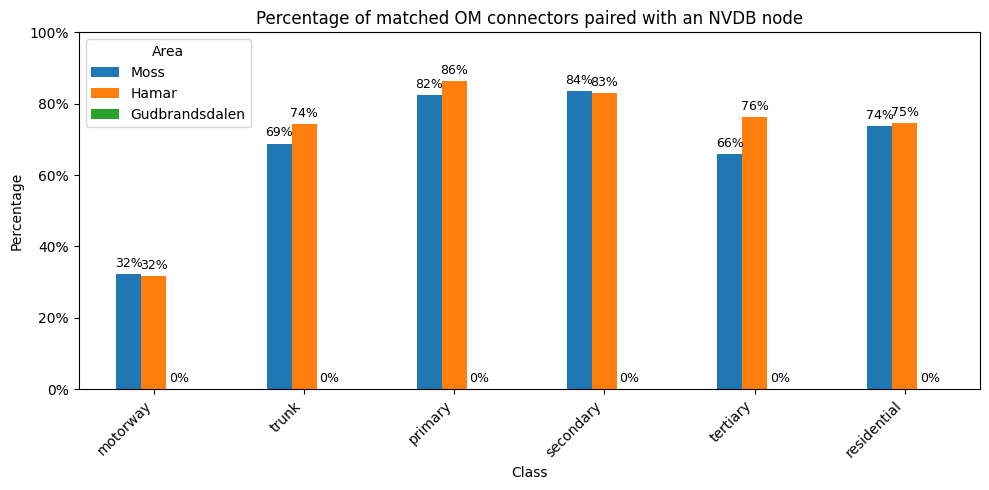

In [10]:

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MultipleLocator

# Desired display order
class_order = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential']
area_order  = ['Moss', 'Hamar', 'Gudbrandsdalen']

# 1) Numerator: rows where both IDs are present
num = matching_df[(matching_df['connector_id'].notna()) & (matching_df['nodeid'].notna())]

# 2) Denominator: rows where connector_id is present (per class & area)
den = matching_df[matching_df['connector_id'].notna()]

# 3) Group counts per (class, Area)
num_counts = num.groupby(['class', 'Area']).size().reset_index(name='num')
den_counts = den.groupby(['class', 'Area']).size().reset_index(name='den')

# 4) Merge and compute percentage within each (class, Area)
counts = den_counts.merge(num_counts, on=['class', 'Area'], how='left').fillna({'num': 0})
counts['pct'] = counts['num'] / counts['den']  # ratio in [0,1]

# 5) Enforce the requested order and ensure all combos appear
counts['class'] = pd.Categorical(counts['class'], categories=class_order, ordered=True)
counts['Area']  = pd.Categorical(counts['Area'],  categories=area_order,  ordered=True)

# 6) Pivot to wide format for grouped bars; reindex to full order and fill missing with 0
pivot = counts.pivot(index='class', columns='Area', values='pct')
pivot = pivot.reindex(index=class_order, columns=area_order).fillna(0)

# 7) Plot
fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax)

# Titles and axis labels (Norwegian)
ax.set_title('Percentage of matched OM connectors paired with an NVDB node')
ax.set_xlabel('Class')
ax.set_ylabel('Percentage')

# Y-axis as percentages from 0% to 100% with ticks every 20%
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.yaxis.set_major_locator(MultipleLocator(0.2))

# X ticks and legend
plt.xticks(rotation=45, ha='right')
ax.legend(title='Area')

# 8) Add data labels on each bar (as percentages)
for container in ax.containers:
    # matplotlib>=3.4: bar_label is available
    ax.bar_label(container, labels=[f"{v.get_height():.0%}" for v in container], padding=3, fontsize=9)

plt.tight_layout()
plt.show()



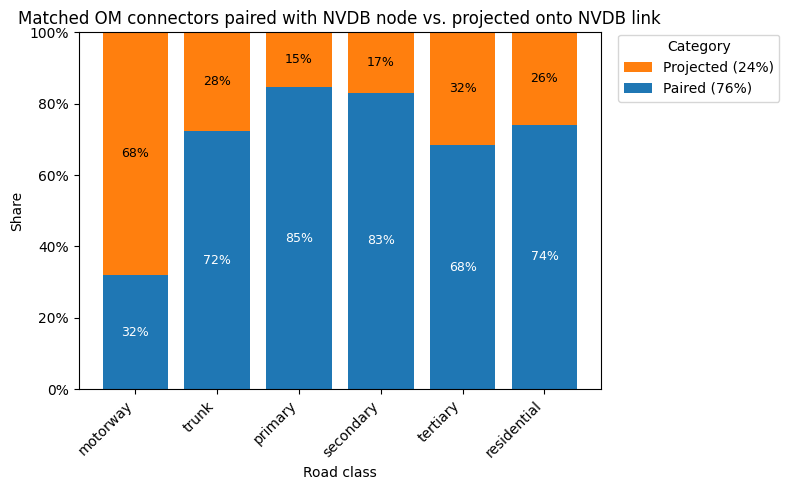

In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MultipleLocator
from matplotlib.patches import Patch

# ----------------------------
# Configuration
# ----------------------------
class_order = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential']

# ----------------------------
# Data preparation
# ----------------------------
# Numerator: rows where both IDs are present
num = matching_df[(matching_df['connector_id'].notna()) & (matching_df['nodeid'].notna())]

# Denominator: rows where connector_id is present
den = matching_df[matching_df['connector_id'].notna()]

# Group counts per class
num_counts = num.groupby('class').size().rename('num').reset_index()
den_counts = den.groupby('class').size().rename('den').reset_index()

# Merge & enforce class order (include missing classes as 0)
counts = den_counts.merge(num_counts, on='class', how='left').fillna({'num': 0})
counts['class'] = pd.Categorical(counts['class'], categories=class_order, ordered=True)
counts = counts.set_index('class').reindex(class_order).fillna({'den': 0, 'num': 0}).reset_index()

# Percentages: Paired (both IDs) and Only connector_id
counts['match_pct'] = np.where(counts['den'] > 0, counts['num'] / counts['den'], 0.0)  # Paired
counts['only_conn_pct'] = np.clip(1.0 - counts['match_pct'], 0.0, 1.0)                 # Projected

# ----------------------------
# Compute overall (summarized) percentages for legend
# ----------------------------
total_den = counts['den'].sum()
total_num = counts['num'].sum()
overall_paired_pct = (total_num / total_den) if total_den > 0 else 0.0
overall_projected_pct = 1.0 - overall_paired_pct

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

x = counts['class']

# Bottom segment: Paired
bars_paired = ax.bar(x, counts['match_pct'], color='tab:blue')
# Top segment: Projected
bars_only   = ax.bar(x, counts['only_conn_pct'], bottom=counts['match_pct'], color='tab:orange')

# Titles and axis labels (English)
ax.set_title('Matched OM connectors paired with NVDB node vs. projected onto NVDB link')
ax.set_xlabel('Road class')
ax.set_ylabel('Share')

# Y-axis as percentages from 0% to 100% with ticks every 20%
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.yaxis.set_major_locator(MultipleLocator(0.2))

# X ticks
plt.xticks(rotation=45, ha='right')

# Deterministic legend outside on the right (order matches stack)
legend_handles = [
    Patch(facecolor='tab:orange', label=f'Projected ({overall_projected_pct:.0%})'),  # top segment
    Patch(facecolor='tab:blue',  label=f'Paired ({overall_paired_pct:.0%})')          # bottom segment
]
ax.legend(handles=legend_handles, title='Category', loc='center left', bbox_to_anchor=(1.02, 0.9))

# Leave room on the right for the legend
fig.subplots_adjust(right=0.82)

# Segment labels (percent of each segment)
ax.bar_label(bars_paired, labels=[f"{b.get_height():.0%}" for b in bars_paired],
             label_type='center', color='white', fontsize=9)
ax.bar_label(bars_only,  labels=[f"{b.get_height():.0%}" for b in bars_only],
             label_type='center', color='black', fontsize=9)

plt.tight_layout()
plt.show()


In [12]:

import pandas as pd
import numpy as np

# Assume merged_df has a column 'distance_to_segment' in meters
# Define bins and labels
bins = [0, 1, 2, 5, 10, np.inf]
labels = ['<1 m', '1–2 m', '2–5 m', '5–10 m', '>10 m']

# Categorize each row by distance
matching_df['distance_cat'] = pd.cut(matching_df['distance_to_segment'], bins=bins, labels=labels, right=False)

# Count rows per category
summary = matching_df.groupby('distance_cat').size().reset_index(name='count')

# Calculate percentage
total = summary['count'].sum()
summary['percent'] = (summary['count'] / total * 100).round(1)

## Display summary
print("\nRow count and percentage per distance category:")
print(summary.to_string(index=False))


Row count and percentage per distance category:
distance_cat  count  percent
        <1 m  22817     68.4
       1–2 m   5364     16.1
       2–5 m   4355     13.1
      5–10 m    813      2.4
       >10 m      0      0.0


C:\Users\JETKNU\AppData\Local\Temp\ipykernel_33684\3908853769.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = matching_df.groupby('distance_cat').size().reset_index(name='count')


C:\Users\JETKNU\AppData\Local\Temp\ipykernel_33684\1463274987.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['class', 'dist_cat']).size().reset_index(name='n')
C:\Users\JETKNU\AppData\Local\Temp\ipykernel_33684\1463274987.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals = df.groupby('class').size().reset_index(name='total')


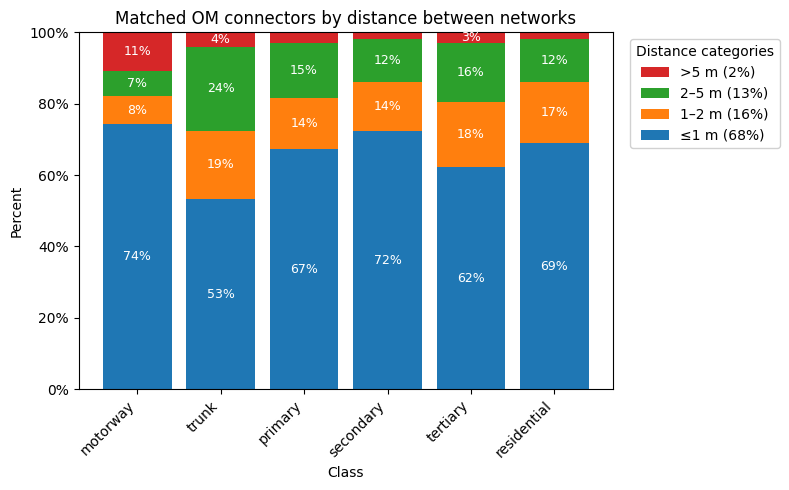

In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MultipleLocator
from matplotlib.patches import Patch

# --- Settings ---
class_order = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential']

bins   = [0.0, 1.0, 2.0, 5.0, np.inf]
labels = ['≤1 m', '1–2 m', '2–5 m', '&gt;5 m']  # keep original labels for binning
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # blue, orange, green, red

min_label_pct  = 0.03   # only label segments >= 3%
bar_width      = 0.55    # your chosen bar width
spacing_factor = 0.67    # < 1.0 reduces center-to-center spacing

# --- Prepare data ---
# merged_df = merged_df[merged_df['connector_id'].notna()].copy()  # optional filter

df = matching_df[['class', 'distance_to_segment']].dropna(subset=['distance_to_segment']).copy()
df['distance_to_segment'] = df['distance_to_segment'].astype(float).clip(lower=0)
df['class'] = pd.Categorical(df['class'], categories=class_order, ordered=True)

# Distance category
df['dist_cat'] = pd.cut(
    df['distance_to_segment'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# Counts and shares
counts = df.groupby(['class', 'dist_cat']).size().reset_index(name='n')
totals = df.groupby('class').size().reset_index(name='total')

shares = counts.merge(totals, on='class', how='left')
shares['pct'] = (shares['n'] / shares['total']).fillna(0.0)

# Ensure full grid
idx = pd.MultiIndex.from_product([class_order, labels], names=['class', 'dist_cat'])
shares = (
    shares.set_index(['class', 'dist_cat'])
          .reindex(idx)
          .fillna({'n': 0, 'total': 0, 'pct': 0.0})
          .reset_index()
)

# Pivot to % matrix (classes × distance bins)
pivot_pct = (
    shares.pivot(index='class', columns='dist_cat', values='pct')
          .reindex(index=class_order, columns=labels)
          .fillna(0.0)
)

# ----------------------------
# Overall (summarized) % per distance bin for legend
# ----------------------------
# Count rows per bin across ALL classes (weighted by row counts)
bin_counts = (
    df['dist_cat']
    .value_counts(dropna=False)
    .reindex(labels)          # ensure same order as 'labels'
    .fillna(0)
    .astype(int)
)
total_rows = int(bin_counts.sum())
overall_pct_by_bin = (bin_counts / total_rows).fillna(0.0) if total_rows > 0 else pd.Series([0.0]*len(labels), index=labels)

# Build display-friendly labels (fix HTML entity just for legend text)
legend_display_labels = [l.replace('&gt;', '>') for l in labels]

# --- Plot with manual stacking & custom spacing ---
fig, ax = plt.subplots(figsize=(8, 5))

classes = pivot_pct.index.tolist()
x_pos = np.arange(len(classes)) * spacing_factor  # shrink center-to-center spacing

# Build stacked bars (bottom accumulates each bin)
bottom = np.zeros(len(classes))
containers = []

for col_idx, (label, color) in enumerate(zip(labels, colors)):
    heights = pivot_pct[label].values
    bars = ax.bar(x_pos, heights, width=bar_width, bottom=bottom, color=color, edgecolor='none')
    containers.append(bars)
    bottom += heights

# Axes formatting
ax.set_title('Matched OM connectors by distance between networks')
ax.set_xlabel('Class')
ax.set_ylabel('Percent')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.yaxis.set_major_locator(MultipleLocator(0.2))

# Class tick labels aligned to positions
ax.set_xticks(x_pos)
ax.set_xticklabels(classes, rotation=45, ha='right')

# Legend outside (top-right), reverse to match bottom-to-top stacking
# Add summarized % per category to each legend label
legend_handles = []
legend_labels_with_pct = []
for lab, col in zip(legend_display_labels[::-1], colors[::-1]):
    pct_val = overall_pct_by_bin[labels[legend_display_labels.index(lab)]]
    legend_handles.append(Patch(facecolor=col, label=lab))
    legend_labels_with_pct.append(f"{lab} ({pct_val:.0%})")

ax.legend(
    handles=legend_handles,
    labels=legend_labels_with_pct,
    title='Distance categories',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    fontsize=10,
    title_fontsize=10,
    frameon=True,
    framealpha=0.9
)

# Tighten layout and leave room for legend if needed
fig.subplots_adjust(right=0.82)
plt.tight_layout()

# --- Percentage labels per segment only ---
for col_idx, bars in enumerate(containers):
    for class_idx, rect in enumerate(bars):
        pct_val = pivot_pct.iloc[class_idx, col_idx]
        if pct_val >= min_label_pct and rect.get_height() > 0:
            x = rect.get_x() + rect.get_width() / 2
            y = rect.get_y() + rect.get_height() / 2
            ax.annotate(f"{pct_val:.0%}",
                        xy=(x, y),
                        va='center', ha='center',
                        fontsize=9, color='white')

plt.show()


## Statistics for LOD

In [14]:
import pandas as pd
from pathlib import Path

# Paths to your files
files = {
    "Hamar": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\segments_lod.xlsx",
    "Moss": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\segments_lod.xlsx",
    "Gudbrandsdalen": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\segments_lod.xlsx",
}

dfs = []

for area, path in files.items():
    # Read Sheet1 explicitly; use the openpyxl engine for .xlsx
    df = pd.read_excel(path, sheet_name="Sheet1", engine="openpyxl")
    # Insert area name as the first column
    df.insert(0, "Area", area)
    print
    dfs.append(df)

# Concatenate into one DataFrame (keeps columns aligned by name)
merged_df = pd.concat(dfs, ignore_index=True)

# Remove one specific segment by its ID
segment_to_remove = '84d1aa20-dcff-425f-911a-fa90c2dd71b2'  # Replace with the actual segment ID to remove      
merged_df = merged_df[merged_df['segment_id'] != segment_to_remove] 

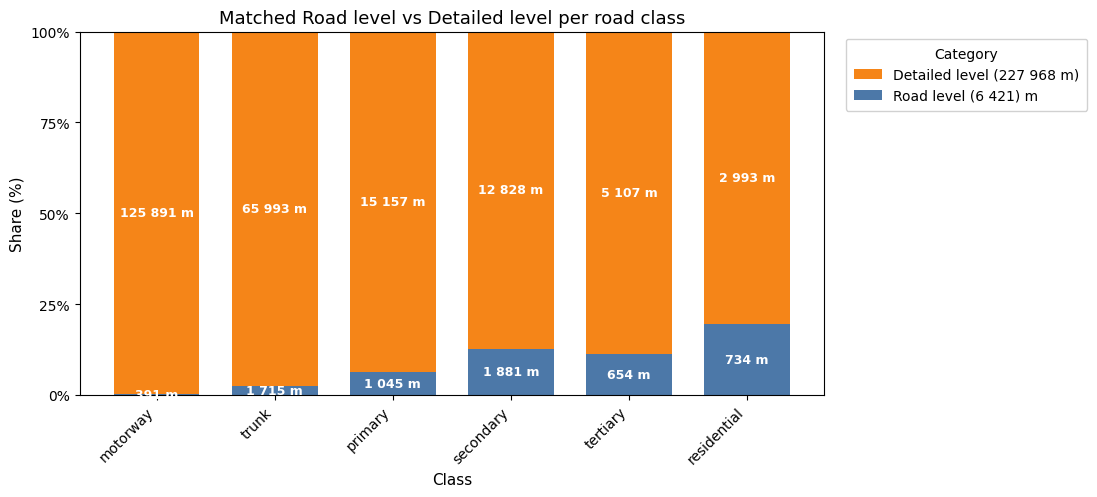

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Settings ---
class_order = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential']

# LOD groups
ROAD_LOD = "Vegtrase"
DETAILED_LODS = {"Kjørebane", "Kjørefelt"}

# --- Aggregate absolute lengths per class (across all Areas) ---
road_c = (
    merged_df[merged_df['lod'] == ROAD_LOD]
    .groupby('class', as_index=True)['length']
    .sum()
    .rename('Road level')
)
detailed_c = (
    merged_df[merged_df['lod'].isin(DETAILED_LODS)]
    .groupby('class', as_index=True)['length']
    .sum()
    .rename('Detailed level')
)

combined_c = pd.concat([road_c, detailed_c], axis=1).fillna(0)
combined_c['Total'] = combined_c['Road level'] + combined_c['Detailed level']

# --- Enforce plotting order by class_order ---
known_in_data = [c for c in class_order if c in combined_c.index]
extra_classes = [c for c in combined_c.index if c not in class_order]
ordered_index = known_in_data + extra_classes
combined_c = combined_c.reindex(ordered_index)

# --- Shares for 100% stacked chart (recompute after ordering) ---
pct_c = combined_c[['Road level', 'Detailed level']].div(combined_c['Total'], axis=0).fillna(0)
classes = combined_c.index

# --- Grand totals across all classes (for legend labels) ---
grand_road = combined_c['Road level'].sum()
grand_detail = combined_c['Detailed level'].sum()

def fmt_num(x):
    # thousands separator using a space (e.g., 12 345)
    return f"{x:,.0f}".replace(",", " ")

# >>> Narrower figure (keep your compact layout) <<<
fig_width = 11 # max(8, min(14, 0.55 * len(classes) + 4))
fig_height = 5
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# --- Control bar spacing (reduced distance) ---
bar_spacing = 0.55  # smaller => tighter spacing; try 0.70 or 0.65 for even tighter
x = np.arange(len(classes)) * bar_spacing

# 100% stacked bars (width = 0.45 as requested)
bar1 = ax.bar(
    x, pct_c['Road level'],
    label=f'Road level ({fmt_num(grand_road)}) m',
    color='#4C78A8',
    width=0.40
)
bar2 = ax.bar(
    x, pct_c['Detailed level'], bottom=pct_c['Road level'],
    label=f'Detailed level ({fmt_num(grand_detail)} m)',
    color='#F58518',
    width=0.40
)

# Cosmetics
ax.set_title('Matched Road level vs Detailed level per road class', fontsize=13)
ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Share (%)', fontsize=11)
ax.set_ylim(0, 1)

# y-axis as percentages
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])

# Put class labels at the numeric positions
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')

# Legend OUTSIDE on the upper-right (like before)
# loc='upper left' + bbox_to_anchor to push it outside the axes on the right
ax.legend(
    handles=[bar2, bar1],       # order matches the stack: detailed (top), then road (bottom)
    title='Category',
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0), # just outside the right edge, top-aligned
    frameon=True,
    framealpha=0.9,
    borderpad=0.6,
)

# Labels: absolute lengths inside each segment, with ' m' appended
for i, cls in enumerate(classes):
    r_abs = combined_c.loc[cls, 'Road level']
    d_abs = combined_c.loc[cls, 'Detailed level']
    r_pct = pct_c.loc[cls, 'Road level']
    d_pct = pct_c.loc[cls, 'Detailed level']

    if r_pct > 0:
        ax.text(
            x[i], r_pct/2, f"{fmt_num(r_abs)} m",
            ha='center', va='center', color='white', fontsize=9, fontweight='bold'
        )
    if d_pct > 0:
        ax.text(
            x[i], r_pct + d_pct/2, f"{fmt_num(d_abs)} m",
            ha='center', va='center', color='white', fontsize=9, fontweight='bold'
        )

# Make room on the right so the legend doesn't get cut off
plt.subplots_adjust(right=0.82)    # increase if legend is still clipped
fig.tight_layout(pad=0.8)

plt.show()

# Statistics for speed limits

In [16]:

import geopandas as gpd
import pandas as pd

files = {
    "Hamar": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\om_nvdb_SpeedLimits.geojson",
    "Moss": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\om_nvdb_SpeedLimits.geojson",
    "Gudbrandsdalen": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\om_nvdb_SpeedLimits.geojson",
}

dfs = []

for area, path in files.items():
    gdf = gpd.read_file(path)
    gdf["Area"] = area
    print(f"Read {len(gdf)} rows from {area} ({path})")
    dfs.append(gdf)

# Concatenate all into one GeoDataFrame
gdf_sl = pd.concat(dfs, ignore_index=True)

#Remove one specific segment by its ID
segment_to_remove = '84d1aa20-dcff-425f-911a-fa90c2dd71b2'  # Replace with the actual segment ID to remove      
gdf_sl = gdf_sl[gdf_sl['segment_id'] != segment_to_remove]  

Read 16651 rows from Hamar (C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\om_nvdb_SpeedLimits.geojson)
Read 12876 rows from Moss (C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\om_nvdb_SpeedLimits.geojson)
Read 6741 rows from Gudbrandsdalen (C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\om_nvdb_SpeedLimits.geojson)


In [17]:

import pandas as pd
import numpy as np

# --- Helper: ensure we have a 'length' column in meters in both GeoDataFrames
def ensure_length_in_meters(gdf, length_col="length", fallback_epsg=25833):
    """
    Returns a copy of gdf with a numeric 'length' column in meters.
    - If length_col exists, it is used (cast to float).
    - Otherwise, compute from geometry. If CRS is geographic (degrees), reproject to fallback_epsg.
    """
    if length_col in gdf.columns:
        return gdf.assign(length=gdf[length_col].astype(float))
    else:
        if getattr(gdf, "crs", None) is None:
            raise ValueError("GeoDataFrame CRS is None. Set an appropriate projected CRS to compute lengths in meters.")
        # Reproject if geographic (degrees)
        if gdf.crs.is_geographic:
            gdf = gdf.to_crs(fallback_epsg)
        return gdf.assign(length=gdf.geometry.length.astype(float))

# --- Prepare input GeoDataFrames
gdf_matched_segments = ensure_length_in_meters(gdf_matched_segments)
gdf_sl               = ensure_length_in_meters(gdf_sl)

# --- Summarize lengths per Area
len_matched = (
    gdf_matched_segments
    .groupby("Area", dropna=False)["length"]
    .sum()
    .rename("length_matched")
)

len_sl = (
    gdf_sl
    .groupby("Area", dropna=False)["length"]
    .sum()
    .rename("length_sl")
)

# --- Merge into comparison table (outer join keeps areas present in only one side)
comparison = (
    pd.concat([len_matched, len_sl], axis=1)
    .fillna(0.0)
)

# --- Metrics: difference and REVERSED percentage (SL vs Matched)
comparison["length_diff"] = comparison["length_matched"] - comparison["length_sl"]
comparison["pct_sl_vs_matched"] = np.where(
    comparison["length_matched"] == 0,
    0.0,
    (comparison["length_sl"] / comparison["length_matched"]) * 100.0
)

# --- Optional: custom area order (Moss → Hamar → Gudbrandsdalen → others)
order = ["Moss", "Hamar", "Gudbrandsdalen"]
order_map = {name: i for i, name in enumerate(order)}
sort_key = comparison.index.to_series().map(order_map).fillna(len(order))
comparison = comparison.assign(_sort=sort_key).sort_values("_sort").drop(columns=["_sort"])

# --- TOTAL row (use sums and compute percentage from totals)
tot_matched = comparison["length_matched"].sum()
tot_sl      = comparison["length_sl"].sum()
tot_diff    = comparison["length_diff"].sum()
tot_pct     = 0.0 if tot_matched == 0 else (tot_sl / tot_matched) * 100.0

total_row = pd.Series({
    "length_matched"    : tot_matched,
    "length_sl"         : tot_sl,
    "length_diff"       : tot_diff,
    "pct_sl_vs_matched" : tot_pct
}, name="TOTAL")

comparison_with_total = pd.concat([comparison, total_row.to_frame().T], axis=0)

# --- Formatting helpers
def fmt_m(val):
    """Format length as integer meters with thousands separator and ' m' suffix."""
    return f"{int(np.rint(val)):,.0f} m"

def fmt_pct(val):
    """Format percentage with one decimal and ' %' suffix."""
    val = 0.0 if pd.isna(val) else float(val)
    return f"{val:.1f} %"

# --- Apply formatting
sl_matching = comparison_with_total.copy()
sl_matching["length_matched"]     = sl_matching["length_matched"].map(fmt_m)
sl_matching["length_sl"]          = sl_matching["length_sl"].map(fmt_m)
sl_matching["length_diff"]        = sl_matching["length_diff"].map(fmt_m)
sl_matching["pct_sl_vs_matched"]  = sl_matching["pct_sl_vs_matched"].map(fmt_pct)

# --- Result
sl_matching


,length_matched,length_sl,length_diff,pct_sl_vs_matched
Moss,"499,499 m","498,628 m",871 m,99.8 %
Hamar,"759,688 m","757,892 m","1,796 m",99.8 %
Gudbrandsdalen,"548,869 m","547,974 m",895 m,99.8 %
TOTAL,"1,808,055 m","1,804,493 m","3,562 m",99.8 %


In [18]:

import pandas as pd
import numpy as np

# --- Robust equality: numeric first, fallback to normalized string equality
has_farts = gdf_sl['Fartsgrense'].notna()
has_max   = gdf_sl['max_speed_value'].notna()
has_both  = has_farts & has_max

farts_num = pd.to_numeric(gdf_sl['Fartsgrense'], errors='coerce')
max_num   = pd.to_numeric(gdf_sl['max_speed_value'], errors='coerce')

numeric_both  = farts_num.notna() & max_num.notna()
numeric_equal = numeric_both & np.isclose(farts_num, max_num)

farts_str = gdf_sl['Fartsgrense'].astype(str).str.strip()
max_str   = gdf_sl['max_speed_value'].astype(str).str.strip()
string_equal = has_both & ~numeric_both & (farts_str == max_str)

equal_both = numeric_equal | string_equal
diff_both  = has_both & ~equal_both  # both present and different

# --- Build one helper frame with per-row contributions
df = gdf_sl.assign(
    length_total     = gdf_sl['length'].astype(float),
    length_equal     = np.where(equal_both, gdf_sl['length'], 0.0),
    length_diff      = np.where(diff_both, gdf_sl['length'], 0.0),
    farts_missing    = np.where(~has_farts, gdf_sl['length'], 0.0),  # missing NVDB
    has_NVDB = np.where(has_farts, gdf_sl['length'], 0.0),  # has NVDB SL
    max_missing      = np.where(~has_max,   gdf_sl['length'], 0.0),  # missing OM
    has_OM      = np.where(has_max,   gdf_sl['length'], 0.0),  # has OM
)

# --- Aggregate by Area
grp = (df
       .groupby('Area', dropna=False)[['length_total','length_equal','length_diff','farts_missing', 'has_NVDB', 'max_missing', 'has_OM']]
       .sum())

# pivot_matched_length

# Use pivot_total_length for denominator
pct_equal        = np.where(pivot_matched_length == 0, 0, grp['length_equal']   / pivot_matched_length)
pct_different    = np.where(pivot_matched_length == 0, 0, grp['length_diff']    / pivot_matched_length)
pct_missing_NVDB = np.where(pivot_matched_length == 0, 0, (pivot_matched_length - grp['has_NVDB'] ) / pivot_matched_length)
pct_missing_OM   = np.where(pivot_matched_length == 0, 0, (pivot_matched_length - grp['has_OM'])    / pivot_matched_length)


# --- Percentages per Area (guard against zero totals) -> fractions
# pct_equal        = np.where(grp['length_total'] == 0, 0, grp['length_equal']   / grp['length_total'])
# pct_different    = np.where(grp['length_total'] == 0, 0, grp['length_diff']    / grp['length_total'])
# pct_missing_NVDB = np.where(grp['length_total'] == 0, 0, grp['farts_missing']  / grp['length_total'])
# pct_missing_OM   = np.where(grp['length_total'] == 0, 0, grp['max_missing']    / grp['length_total'])

# --- Build output (fractions -> percentage 0–100, one decimal; length -> whole meters)
out = pd.DataFrame({
    'Percentage equal'        : np.round(pct_equal * 100, 1),
    'Percentage different'    : np.round(pct_different * 100, 1),
    'Length different'        : np.rint(grp['length_diff']).astype(int),
    'Percentage missing NVDB' : np.round(pct_missing_NVDB * 100, 1),
    'Percentage missing OM'   : np.round(pct_missing_OM * 100, 1),
}, index=grp.index)

# --- Custom area order: Moss, Hamar, Gudbrandsdalen (others follow), Total last
order = ['Moss', 'Hamar', 'Gudbrandsdalen']
order_map = {name: i for i, name in enumerate(order)}
sort_key = out.index.to_series().map(order_map).fillna(len(order))  # unknown areas after known ones
out = out.assign(_sort=sort_key).sort_values('_sort').drop(columns=['_sort'])

# --- Append TOTAL row with percentages computed from overall totals (not averaged)
tot_length_total   = pivot_matched_length.sum() # grp['length_total'].sum()
tot_equal          = grp['length_equal'].sum()
tot_diff           = grp['length_diff'].sum()
tot_missing_NVDB   = (pivot_matched_length - grp['has_NVDB'] ).sum()
tot_missing_OM     = (pivot_matched_length - grp['has_OM']) .sum()

# Fractions for total -> then format
total_pct_equal        = 0 if tot_length_total == 0 else tot_equal        / tot_length_total
total_pct_different    = 0 if tot_length_total == 0 else tot_diff         / tot_length_total
total_pct_missing_NVDB = 0 if tot_length_total == 0 else tot_missing_NVDB / tot_length_total
total_pct_missing_OM   = 0 if tot_length_total == 0 else tot_missing_OM   / tot_length_total

total_row = pd.Series({
    'Percentage equal'        : np.round(total_pct_equal * 100, 1),
    'Percentage different'    : np.round(total_pct_different * 100, 1),
    'Length different'        : int(np.rint(tot_diff)),
    'Percentage missing NVDB' : np.round(total_pct_missing_NVDB * 100, 1),
    'Percentage missing OM'   : np.round(total_pct_missing_OM * 100, 1),
}, name='Total for all areas')

final = pd.concat([out, total_row.to_frame().T], axis=0)

# Show length values with o decimals, thousands separator and " m" suffix   
final['Length different'] = final['Length different'].apply(lambda x: f"{x:,.0f} m")
# Show percentage values with one decimal place and a "%" suffix    
percentage_columns = [
    'Percentage equal',
    'Percentage different',
    'Percentage missing NVDB',
    'Percentage missing OM'
]
for col in percentage_columns:
    final[col] = final[col].apply(lambda x: f"{x:.1f} %")          

final  # <- ordered table (Moss, Hamar, Gudbrandsdalen, then others, then Total), formatted as requested



,Percentage equal,Percentage different,Length different,Percentage missing NVDB,Percentage missing OM
Moss,66.7 %,6.0 %,"30,197 m",0.2 %,27.3 %
Hamar,72.0 %,6.2 %,"47,432 m",0.4 %,21.7 %
Gudbrandsdalen,82.0 %,6.3 %,"34,509 m",0.4 %,11.5 %
Total for all areas,73.6 %,6.2 %,"112,137 m",0.3 %,20.1 %


In [19]:

import pandas as pd
import numpy as np

# --- Helper: robust numeric extraction (e.g., "50 km/h", "30,0" -> 30.0)
def to_numeric_series(s):
    s_str = s.astype(str).str.replace(',', '.', regex=False).str.lower()
    # Extract a number, optionally followed by 'km/h' (does not require it)
    extracted = s_str.str.extract(r'(\d+\.?\d*)\s*(?:km/?h)?', expand=False)
    return pd.to_numeric(extracted, errors='coerce')

# --- Prepare numeric speed columns (NVDB vs OM)
farts_num = to_numeric_series(gdf_sl['Fartsgrense'])      # NVDB
max_num   = to_numeric_series(gdf_sl['max_speed_value'])  # OM

# --- Deviation masks (numeric-only rows)
has_both_numeric  = farts_num.notna() & max_num.notna()
mask_max_gt_farts = has_both_numeric & (max_num > farts_num)    # OM > NVDB
mask_farts_gt_max = has_both_numeric & (farts_num > max_num)    # NVDB > OM
mask_deviation    = mask_max_gt_farts | mask_farts_gt_max

# --- Aggregate per Area
sum_deviation = (
    gdf_sl.loc[mask_deviation]
          .groupby('Area', dropna=False)['length']
          .sum()
          .rename('Deviation length')        # renamed
)

sum_max_gt_farts = (
    gdf_sl.loc[mask_max_gt_farts]
          .groupby('Area', dropna=False)['length']
          .sum()
          .rename('Length OM>NVDB')          # renamed
)

sum_farts_gt_max = (
    gdf_sl.loc[mask_farts_gt_max]
          .groupby('Area', dropna=False)['length']
          .sum()
          .rename('Length NVDB>OM')          # renamed
)

# --- Build summary frame and ensure numeric types; fill missing areas with 0
summary_dev = (
    pd.concat([sum_deviation, sum_max_gt_farts, sum_farts_gt_max], axis=1)
      .fillna(0.0)
      .reset_index()
)

# --- Percentages within deviation per Area (guard against division by zero)
summary_dev['OM>NVDB (%)'] = np.where(
    summary_dev['Deviation length'] == 0, 0.0,
    summary_dev['Length OM>NVDB'] / summary_dev['Deviation length'] * 100
).round(1)

summary_dev['NVDB>OM (%)'] = np.where(
    summary_dev['Deviation length'] == 0, 0.0,
    summary_dev['Length NVDB>OM'] / summary_dev['Deviation length'] * 100
).round(1)

# --- Format lengths (whole meters)
length_cols = ['Deviation length', 'Length OM>NVDB', 'Length NVDB>OM']
summary_dev[length_cols] = np.rint(summary_dev[length_cols]).astype('int64')

# --- Sort areas: Moss, Hamar, Gudbrandsdalen (others after)
summary_dev['Area'] = summary_dev['Area'].astype(str)
order = ['Moss', 'Hamar', 'Gudbrandsdalen']
order_map = {name: i for i, name in enumerate(order)}
sort_key = summary_dev['Area'].map(order_map).fillna(len(order))
summary_dev = summary_dev.assign(_sort=sort_key).sort_values('_sort').drop(columns=['_sort'])

# --- Compute totals from UNROUNDED sums to avoid rounding drift; then format
float_total_deviation = sum_deviation.sum()
float_total_om_gt     = sum_max_gt_farts.sum()
float_total_nvdb_gt   = sum_farts_gt_max.sum()

if float_total_deviation == 0:
    tot_pct_om_gt   = 0.0
    tot_pct_nvdb_gt = 0.0
else:
    tot_pct_om_gt   = round((float_total_om_gt  / float_total_deviation) * 100, 1)
    tot_pct_nvdb_gt = round((float_total_nvdb_gt / float_total_deviation) * 100, 1)

total_row = pd.DataFrame([{
    'Area': 'Total for all areas',
    'Deviation length':  int(np.rint(float_total_deviation)),
    'Length OM>NVDB':    int(np.rint(float_total_om_gt)),
    'OM>NVDB (%)':       tot_pct_om_gt,
    'Length NVDB>OM':    int(np.rint(float_total_nvdb_gt)),
    'NVDB>OM (%)':       tot_pct_nvdb_gt,
}])

final_dev = pd.concat([summary_dev, total_row], ignore_index=True)

# --- Reorder columns to the requested layout
final_dev = final_dev[['Area',
                       'Deviation length',
                       'Length OM>NVDB',
                       'OM>NVDB (%)',
                       'Length NVDB>OM',
                       'NVDB>OM (%)']]

# Show length values with 0 decimals, thousands separator and " m" suffix   
length_columns = ['Deviation length', 'Length OM>NVDB', 'Length NVDB>OM']
for col in length_columns:
    final_dev[col] = final_dev[col].apply(lambda x: f"{x:,.0f} m")  
# Show percentage values with one decimal place and a "%" suffix    
percentage_columns = ['OM>NVDB (%)', 'NVDB>OM (%)']
for col in percentage_columns:
    final_dev[col] = final_dev[col].apply(lambda x: f"{x:.1f} %")   

# --- Final output
final_dev


,Area,Deviation length,Length OM>NVDB,OM>NVDB (%),Length NVDB>OM,NVDB>OM (%)
0,Moss,"30,197 m","17,809 m",59.0 %,"12,388 m",41.0 %
1,Hamar,"47,432 m","33,030 m",69.6 %,"14,402 m",30.4 %
2,Gudbrandsdalen,"34,509 m","26,817 m",77.7 %,"7,692 m",22.3 %
3,Total for all areas,"112,137 m","77,656 m",69.3 %,"34,481 m",30.7 %


C:\Users\JETKNU\AppData\Local\Temp\ipykernel_33684\2072180741.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{y/1000:.1f} km' for y in ax.get_yticks()])


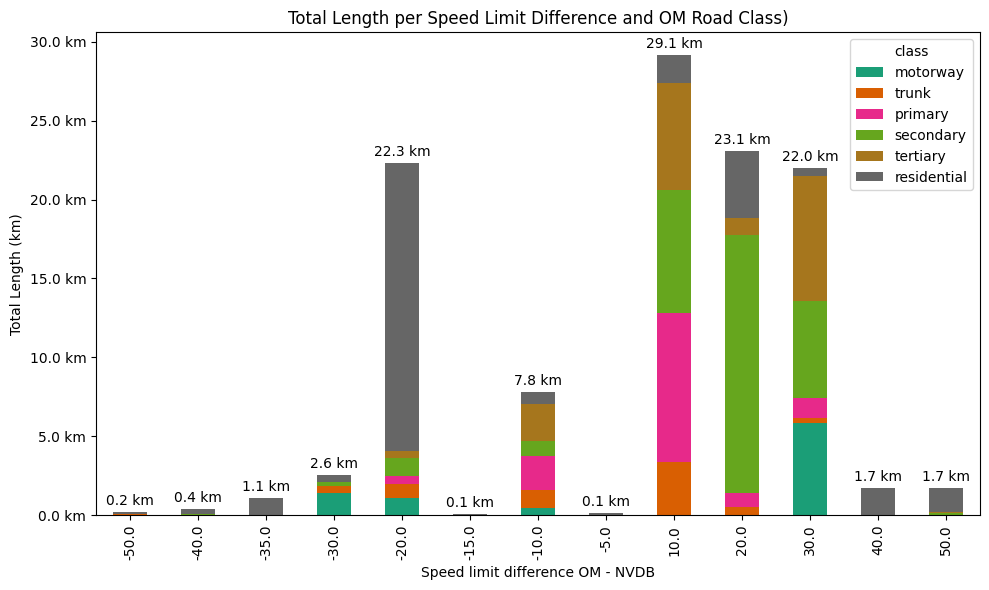

In [20]:
# Define desired class order
class_order = ['motorway','trunk','primary','secondary', 'tertiary', 'residential']

# Ensure 'Diff' is numeric
gdf_sl['Diff'] = pd.to_numeric(gdf_sl['Diff'], errors='coerce')
# Filter rows where max_speed_value is not equal to Fartsgrense
sl_Deviations = gdf_sl[(gdf_sl['max_speed_value'] != gdf_sl['Fartsgrense']) & (gdf_sl['Fartsgrense'].notna()) & (gdf_sl['max_speed_value'].notna())].copy()
# Drop rows with NaN in 'Diff', 'length', or 'class'
sl_Deviations = sl_Deviations.dropna(subset=['Diff', 'length', 'class'])

# Group by 'Diff' and 'class', sum length in meters
grouped_m = sl_Deviations.groupby(['Diff', 'class'])['length'].sum().unstack(fill_value=0).sort_index()

# Reindex columns to match desired class order (missing classes will be filled with 0)
grouped_m = grouped_m.reindex(columns=class_order, fill_value=0)

# Plot stacked bar chart using brighter color palette
fig, ax = plt.subplots(figsize=(10, 6))
grouped_m.plot(kind='bar', stacked=True, ax=ax, colormap='Dark2')

# Convert y-axis to kilometers
ax.set_yticklabels([f'{y/1000:.1f} km' for y in ax.get_yticks()])

# Add total labels in km on top of each bar
for idx, total_m in enumerate(grouped_m.sum(axis=1)):
    total_km = total_m / 1000
    ax.annotate(f'{total_km:.1f} km',
                xy=(idx, total_m),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

# Set labels and title
plt.xlabel('Speed limit difference OM - NVDB')
plt.ylabel('Total Length (km)')
plt.title('Total Length per Speed Limit Difference and OM Road Class)')
plt.tight_layout()
plt.show()

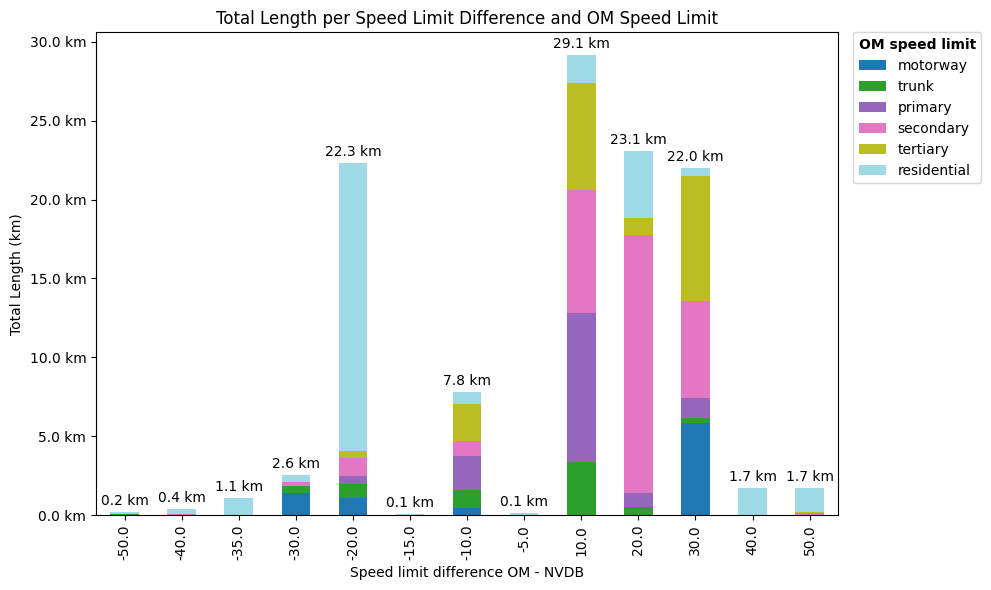

In [21]:

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
grouped_m.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

# Legend outside on the right, with a title inside the legend box
leg = ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=True,
    title='OM speed limit',           # <- title inside legend
)
leg.set_title('OM speed limit')
leg._legend_box.align = "left"        # optional: left-align title with entries
leg.get_title().set_fontweight('bold')  # optional styling
leg.get_title().set_fontsize(10)

# Make room on the right
plt.subplots_adjust(right=0.80)

# Y-axis formatter (km)
import matplotlib.ticker as mticker
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, pos: f'{y/1000:.1f} km'))

# Total labels on bars
for idx, total_m in enumerate(grouped_m.sum(axis=1)):
    ax.annotate(
        f'{total_m/1000:.1f} km',
        xy=(idx, total_m),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center', va='bottom'
    )

plt.xlabel('Speed limit difference OM - NVDB')
plt.ylabel('Total Length (km)')
plt.title('Total Length per Speed Limit Difference and OM Speed Limit')
plt.tight_layout()
plt.show()



<module 'matplotlib.pyplot' from 'C:\\Users\\JETKNU\\AppData\\Roaming\\Python\\Python312\\site-packages\\matplotlib\\pyplot.py'>

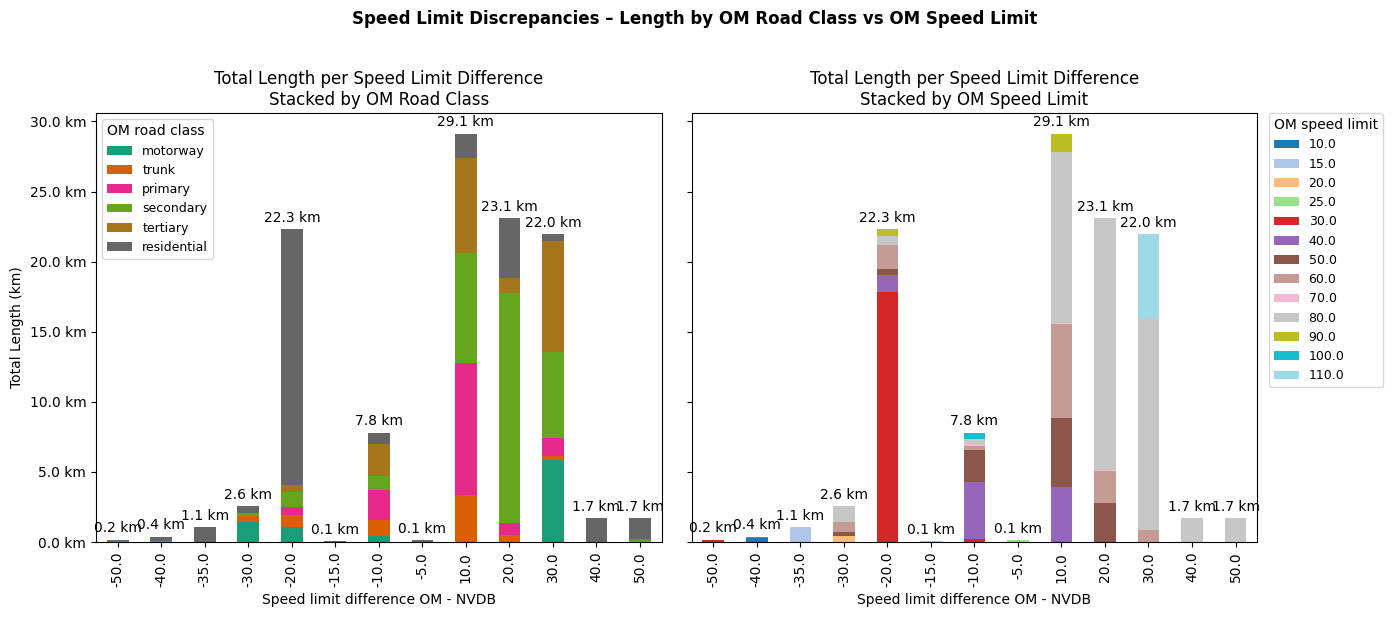

In [22]:

# --- Prep & filtering ---------------------------------------------------------
# Desired plotting order for classes
class_order = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential']

# Ensure 'Diff' is numeric
gdf_sl['Diff'] = pd.to_numeric(gdf_sl['Diff'], errors='coerce')

# Keep rows where OM max_speed_value != NVDB Fartsgrense and both exist
sl_Deviations = gdf_sl[
    (gdf_sl['max_speed_value'] != gdf_sl['Fartsgrense']) &
    (gdf_sl['Fartsgrense'].notna()) &
    (gdf_sl['max_speed_value'].notna())
].copy()

# Drop rows with NaN in critical columns
sl_Deviations = sl_Deviations.dropna(subset=['Diff', 'length', 'class'])

# If max_speed_value may be strings, ensure numeric for sorting
sl_Deviations['max_speed_value'] = pd.to_numeric(sl_Deviations['max_speed_value'], errors='coerce')

# --- Groupings for the two charts --------------------------------------------
# LEFT: group by Diff x class (sum of length)
grouped_class = (
    sl_Deviations.groupby(['Diff', 'class'])['length']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# Reindex columns to desired class order (fill missing with 0)
grouped_class = grouped_class.reindex(columns=class_order, fill_value=0)

# RIGHT: group by Diff x max_speed_value (sum of length)
grouped_speed = (
    sl_Deviations.groupby(['Diff', 'max_speed_value'])['length']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# Sort speed columns numerically
grouped_speed = grouped_speed[sorted(grouped_speed.columns)]

# --- Plotting side-by-side ----------------------------------------------------
fig, axes = plt.subplots(ncols=2, figsize=(14, 6), sharey=True)

# Common y-axis formatter in km
km_formatter = mticker.FuncFormatter(lambda y, pos: f'{y/1000:.1f} km')

# LEFT chart: OM Road Class
grouped_class.plot(kind='bar', stacked=True, ax=axes[0], colormap='Dark2')
axes[0].set_title('Total Length per Speed Limit Difference\nStacked by OM Road Class')
axes[0].set_xlabel('Speed limit difference OM - NVDB')
axes[0].set_ylabel('Total Length (km)')
axes[0].yaxis.set_major_formatter(km_formatter)

# Totals on top of each bar (same totals across both charts)
totals_left = grouped_class.sum(axis=1)
for idx, total_m in enumerate(totals_left):
    axes[0].annotate(
        f'{total_m/1000:.1f} km',
        xy=(idx, total_m),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center', va='bottom'
    )

# Legend for classes (kept inside on the left to avoid crowding)
leg_class = axes[0].legend(title='OM road class', frameon=True, fontsize=9)
leg_class._legend_box.align = "left"

# RIGHT chart: OM Speed Limit
grouped_speed.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Total Length per Speed Limit Difference\nStacked by OM Speed Limit')
axes[1].set_xlabel('Speed limit difference OM - NVDB')
axes[1].yaxis.set_major_formatter(km_formatter)

totals_right = grouped_speed.sum(axis=1)
for idx, total_m in enumerate(totals_right):
    axes[1].annotate(
        f'{total_m/1000:.1f} km',
        xy=(idx, total_m),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center', va='bottom'
    )

# Legend outside on the right for speed limits
leg_speed = axes[1].legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=True,
    title='OM speed limit',
    fontsize=9
)
leg_speed._legend_box.align = "left"
# leg_speed.get_title().set_fontweight('bold')
leg_speed.get_title().set_fontsize(10)

# Make room for the external legend
plt.subplots_adjust(right=0.80)

# Optional: overall figure title
fig.suptitle('Speed Limit Discrepancies – Length by OM Road Class vs OM Speed Limit', y=1.02, fontsize=12, fontweight='bold')

# Tidy layout
plt.tight_layout()
plt


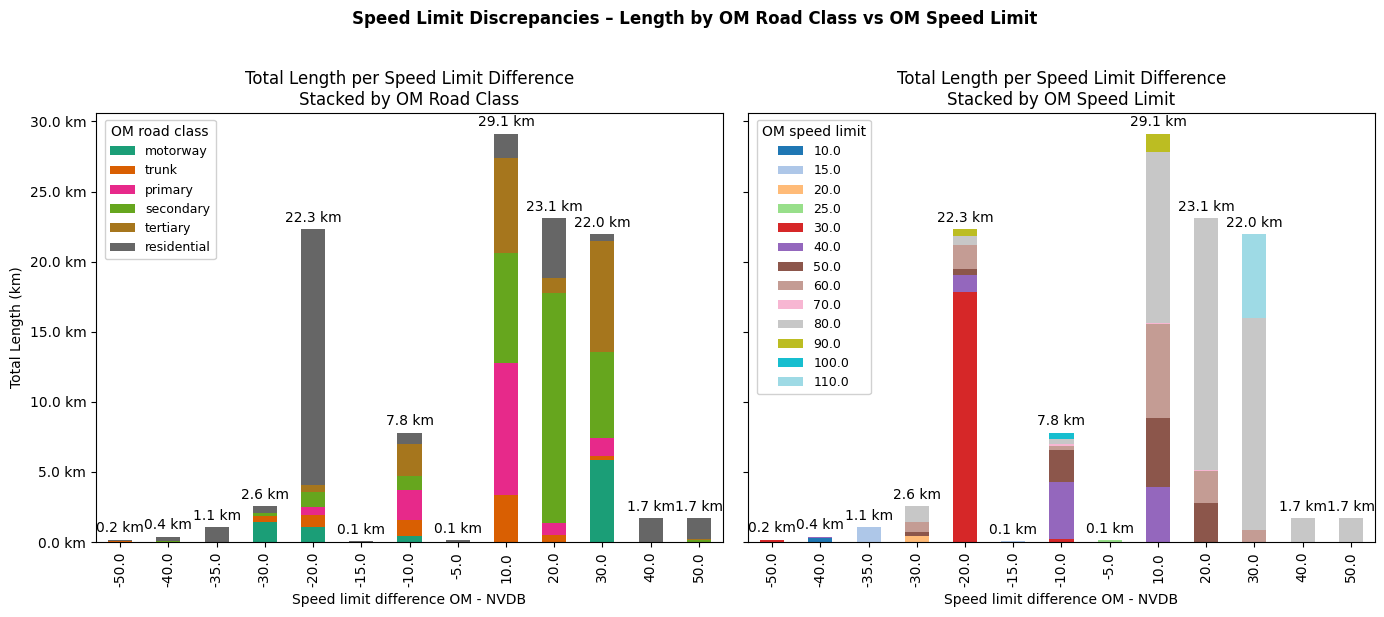

In [23]:

# --- Prep & filtering ---------------------------------------------------------
# Desired plotting order for classes
class_order = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential']

# Ensure 'Diff' is numeric
gdf_sl['Diff'] = pd.to_numeric(gdf_sl['Diff'], errors='coerce')

# Keep rows where OM max_speed_value != NVDB Fartsgrense and both exist
sl_Deviations = gdf_sl[
    (gdf_sl['max_speed_value'] != gdf_sl['Fartsgrense']) &
    (gdf_sl['Fartsgrense'].notna()) &
    (gdf_sl['max_speed_value'].notna())
].copy()

# Drop rows with NaN in critical columns
sl_Deviations = sl_Deviations.dropna(subset=['Diff', 'length', 'class'])

# If max_speed_value may be strings, ensure numeric for sorting
sl_Deviations['max_speed_value'] = pd.to_numeric(sl_Deviations['max_speed_value'], errors='coerce')

# --- Groupings for the two charts --------------------------------------------
# LEFT: group by Diff x class (sum of length)
grouped_class = (
    sl_Deviations.groupby(['Diff', 'class'])['length']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# Reindex columns to desired class order (fill missing with 0)
grouped_class = grouped_class.reindex(columns=class_order, fill_value=0)

# RIGHT: group by Diff x max_speed_value (sum of length)
grouped_speed = (
    sl_Deviations.groupby(['Diff', 'max_speed_value'])['length']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# Sort speed columns numerically
grouped_speed = grouped_speed[sorted(grouped_speed.columns)]

# --- Plotting side-by-side ----------------------------------------------------
fig, axes = plt.subplots(ncols=2, figsize=(14, 6), sharey=True)

# Common y-axis formatter in km
km_formatter = mticker.FuncFormatter(lambda y, pos: f'{y/1000:.1f} km')

# LEFT chart: OM Road Class
grouped_class.plot(kind='bar', stacked=True, ax=axes[0], colormap='Dark2')
axes[0].set_title('Total Length per Speed Limit Difference\nStacked by OM Road Class')
axes[0].set_xlabel('Speed limit difference OM - NVDB')
axes[0].set_ylabel('Total Length (km)')
axes[0].yaxis.set_major_formatter(km_formatter)

# Totals on top of each bar (same totals across both charts)
totals_left = grouped_class.sum(axis=1)
for idx, total_m in enumerate(totals_left):
    axes[0].annotate(
        f'{total_m/1000:.1f} km',
        xy=(idx, total_m),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center', va='bottom'
    )

# Legend INSIDE (top-left) for classes
leg_class = axes[0].legend(
    title='OM road class',
    fontsize=9,
    loc='upper left',
    bbox_to_anchor=(0.01, 0.99),  # slight inset from the top-left corner
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    borderaxespad=0.2
)
for text in leg_class.get_texts():
    text.set_ha('left')
leg_class.get_title().set_fontsize(10)

# RIGHT chart: OM Speed Limit
grouped_speed.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Total Length per Speed Limit Difference\nStacked by OM Speed Limit')
axes[1].set_xlabel('Speed limit difference OM - NVDB')
axes[1].yaxis.set_major_formatter(km_formatter)

totals_right = grouped_speed.sum(axis=1)
for idx, total_m in enumerate(totals_right):
    axes[1].annotate(
        f'{total_m/1000:.1f} km',
        xy=(idx, total_m),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center', va='bottom'
    )

# Legend INSIDE (top-left) for speed limits
leg_speed = axes[1].legend(
    title='OM speed limit',
    fontsize=9,
    loc='upper left',
    bbox_to_anchor=(0.01, 0.99),
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    borderaxespad=0.2
)
for text in leg_speed.get_texts():
    text.set_ha('left')
leg_speed.get_title().set_fontsize(10)

# Removed external legend and extra right margin
# plt.subplots_adjust(right=0.80)

# Optional: overall figure title
fig.suptitle('Speed Limit Discrepancies – Length by OM Road Class vs OM Speed Limit',
             y=1.02, fontsize=12, fontweight='bold')

# Tidy layout
plt.tight_layout()
plt.show()



In [24]:

import pandas as pd

# --- Ensure segment_id has the same dtype in both dataframes ---
gdf_sl['segment_id'] = gdf_sl['segment_id'].astype(str)
gdf_matched_segments['segment_id'] = gdf_matched_segments['segment_id'].astype(str)

# --- Build a lookup table with one class per segment_id ---
# If gdf_matched_segments can contain duplicates per segment_id, pick the most frequent class
class_lookup = (
    gdf_matched_segments
    .dropna(subset=['segment_id', 'class'])
    .groupby('segment_id')['class']
    .agg(lambda s: s.value_counts().index[0])  # "mode"
    .to_frame('class_from_matched')
)

# --- Join lookup into gdf_sl ---
gdf_sl = gdf_sl.join(class_lookup, on='segment_id')

# --- Fill only missing classes in gdf_sl ---
gdf_sl['class'] = gdf_sl['class'].fillna(gdf_sl['class_from_matched'])

# --- Cleanup helper column ---
gdf_sl = gdf_sl.drop(columns=['class_from_matched'])

# Optional sanity checks
print("Missing class after fill:", gdf_sl['class'].isna().sum())


Missing class after fill: 0


C:\Users\JETKNU\AppData\Local\Temp\ipykernel_33684\456596906.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{y/1000:.1f} km' for y in ax.get_yticks()])


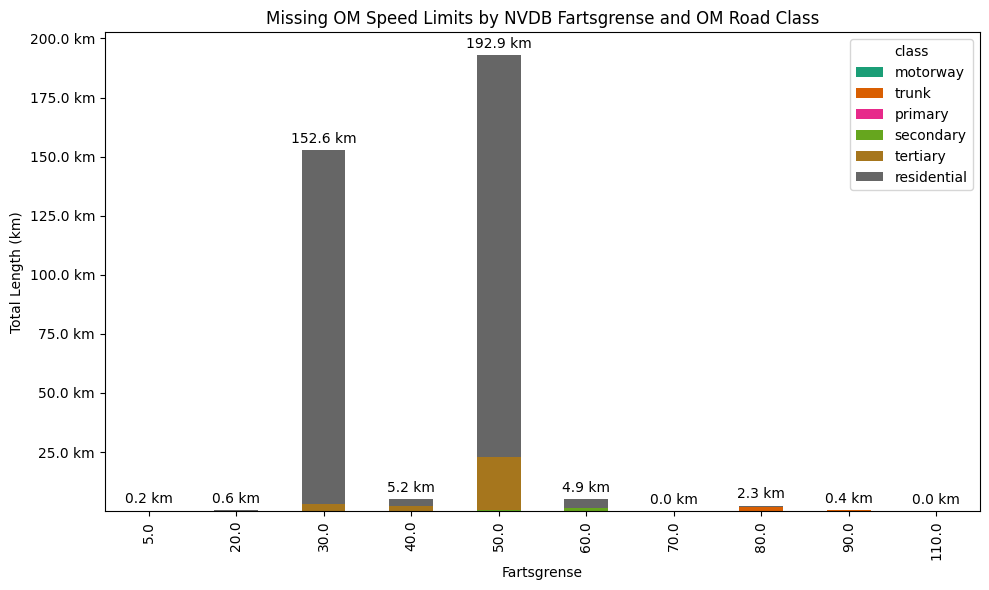

In [25]:

# Desired class order
class_order = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential']

# Ensure length is numeric
gdf_sl['length'] = pd.to_numeric(gdf_sl['length'], errors='coerce')

# Filter rows where max_speed_value is missing but Fartsgrense is known
sl_missing_maxspeed = gdf_sl[
    gdf_sl['max_speed_value'].isna() &
    gdf_sl['Fartsgrense'].notna() &
    gdf_sl['class'].notna()
].copy()

# Drop rows with missing length
sl_missing_maxspeed = sl_missing_maxspeed.dropna(subset=['length'])

# Group by Fartsgrense and class, summing length (meters)
grouped_m = (
    sl_missing_maxspeed
    .groupby(['Fartsgrense', 'class'])['length']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# Reindex columns to enforce class order
grouped_m = grouped_m.reindex(columns=class_order, fill_value=0)

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
grouped_m.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='Dark2'
)

# Convert y-axis labels to kilometers
ax.set_yticklabels([f'{y/1000:.1f} km' for y in ax.get_yticks()])

# Add total length labels on top of each bar
for idx, total_m in enumerate(grouped_m.sum(axis=1)):
    total_km = total_m / 1000
    ax.annotate(
        f'{total_km:.1f} km',
        xy=(idx, total_m),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom'
    )

# Labels and title
ax.set_xlabel('Fartsgrense')
ax.set_ylabel('Total Length (km)')
ax.set_title('Missing OM Speed Limits by NVDB Fartsgrense and OM Road Class')

plt.tight_layout()
plt.show()



# Statistics for traffic flow direction

In [26]:
import geopandas as gpd
import pandas as pd

files = {
    "Hamar": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\om_nvdb_directions.geojson",
    "Moss": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\om_nvdb_directions.geojson",
    "Gudbrandsdalen": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\om_nvdb_directions.geojson",
}

dfs = []

for area, path in files.items():
    print(f"Reading {area} from {path}...") 
    gdf = gpd.read_file(path)
    gdf["Area"] = area
    print(f"  Read {len(gdf)} records." )
    dfs.append(gdf)

# Concatenate all into one GeoDataFrame
gdf_tfd = pd.concat(dfs, ignore_index=True)

# Remove one specific segment by its ID
segment_to_remove = '84d1aa20-dcff-425f-911a-fa90c2dd71b2'  # Replace with the actual segment ID to remove      
gdf_tfd = gdf_tfd[gdf_tfd['segment_id'] != segment_to_remove]


Reading Hamar from C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\om_nvdb_directions.geojson...
  Read 2587 records.
Reading Moss from C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\om_nvdb_directions.geojson...
  Read 3116 records.
Reading Gudbrandsdalen from C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\om_nvdb_directions.geojson...
  Read 722 records.


In [27]:

import pandas as pd

# Ensure 'length' is numeric
gdf_tfd = gdf_tfd.copy()
gdf_tfd["length"] = pd.to_numeric(gdf_tfd["length"], errors="coerce").fillna(0)

# Pivot: sum length per Area × dt_comparison
pivot = (
    gdf_tfd.pivot_table(
        index="Area",
        columns="dt_comparison",
        values="length",
        aggfunc="sum",
        fill_value=0,
        dropna=False,
    )
)

# Ensure columns exist and order them: Both, Only OM, Only NVDB
for col in ["Both", "Only OM", "Only NVDB"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["Both", "Only OM", "Only NVDB"]]

# Add row totals
pivot["All"] = pivot.sum(axis=1)

# Add percentage columns (share of row total)
den = pivot["All"].replace({0: pd.NA})
pivot["% Both"]      = (pivot["Both"] / den) * 100
pivot["% Only OM"]   = (pivot["Only OM"] / den) * 100
pivot["% Only NVDB"] = (pivot["Only NVDB"] / den) * 100

# Add grand total row
total_row = pivot[["Both", "Only OM", "Only NVDB", "All"]].sum().to_frame().T
total_row.index = ["All"]
overall = total_row["All"].iloc[0]
total_row["% Both"]      = (total_row["Both"]      / overall) * 100 if overall else 0
total_row["% Only OM"]   = (total_row["Only OM"]   / overall) * 100 if overall else 0
total_row["% Only NVDB"] = (total_row["Only NVDB"] / overall) * 100 if overall else 0

# Combine
result = pd.concat([pivot, total_row])

# Reorder columns: All first, then Both, Only OM, Only NVDB, then percentages
result = result[["All", "Both", "Only OM", "Only NVDB", "% Both", "% Only OM", "% Only NVDB"]]

# --- Length values as integers (whole meters)
length_cols = ["All", "Both", "Only OM", "Only NVDB"]
result[length_cols] = result[length_cols].round(0).astype("int64")

# --- Percentages rounded to one decimal
result[["% Both", "% Only OM", "% Only NVDB"]] = result[["% Both", "% Only OM", "% Only NVDB"]].round(1)

# --- Sort by Area: Moss, Hamar, Gudbrandsdalen, then All (explicit reindex)
order = ["Moss", "Hamar", "Gudbrandsdalen", "All"]
result = result.reindex(order)


# --- Reorder columns so % columns follow their respective length columns
result = result[
    ["All", 
     "Both", "% Both", 
     "Only OM", "% Only OM", 
     "Only NVDB", "% Only NVDB"]]

# rename first column from 'dt_comparison' to 'Area'
result  = result.rename_axis('Area').reset_index().set_index('Area') 

result = result.rename(index={"All": "Total for all areas"})    
# Show length values with 0 decimals, thousands separator and " m" suffix   
for col in length_cols:
    result[col] = result[col].apply(lambda x: f"{x:,.0f} m")  
# Show percentage values with one decimal place and a "%" suffix    
percentage_columns = ["% Both", "% Only OM", "% Only NVDB"]
for col in percentage_columns:
    result[col] = result[col].apply(lambda x: f"{x:.1f} %")
# Rename 'All' column to 'Total length' 
result = result.rename(columns={"All": "Total length"})
# Final output
result



dt_comparison,Total length,Both,% Both,Only OM,% Only OM,Only NVDB,% Only NVDB
Area,,,,,,,
Moss,"101,406 m","91,154 m",89.9 %,"7,460 m",7.4 %,"2,792 m",2.8 %
Hamar,"120,367 m","111,060 m",92.3 %,"3,339 m",2.8 %,"5,969 m",5.0 %
Gudbrandsdalen,"61,003 m","58,161 m",95.3 %,"1,493 m",2.4 %,"1,349 m",2.2 %
Total for all areas,"282,777 m","260,375 m",92.1 %,"12,291 m",4.3 %,"10,110 m",3.6 %


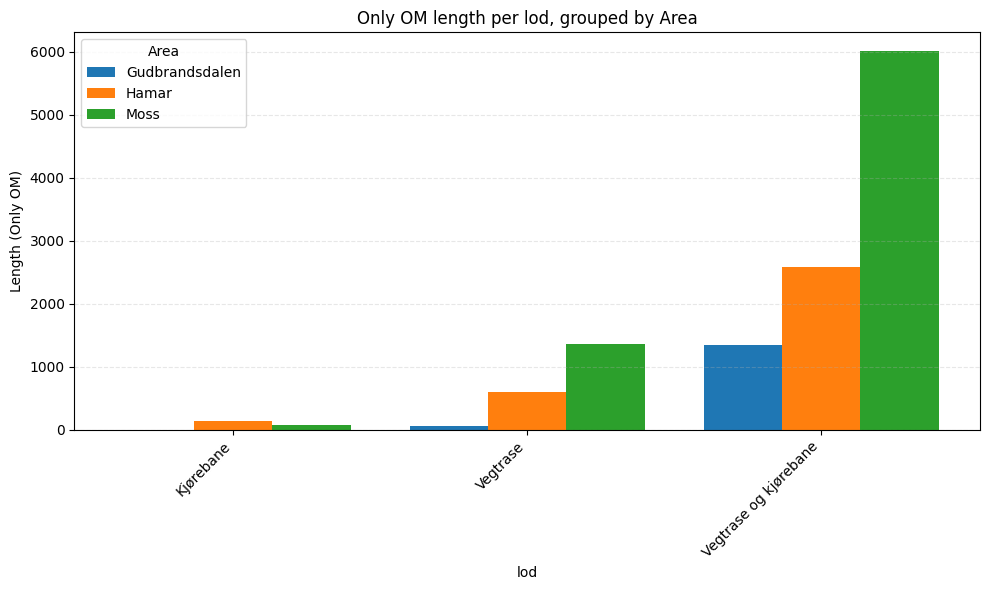

In [28]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter to Only OM
df = gdf_tfd[gdf_tfd["dt_comparison"] == "Only OM"].copy()
df["length"] = pd.to_numeric(df["length"], errors="coerce").fillna(0)

# Aggregate length per class × Area
summary = (
    df.groupby(["lod", "Area"])["length"]
      .sum()
      .reset_index()
)

# Pivot: rows = class, columns = Area, values = length
pivot = summary.pivot(index="lod", columns="Area", values="length").fillna(0)

classes = pivot.index.tolist()
areas = pivot.columns.tolist()

x = np.arange(len(classes))
bar_width = 0.8 / max(len(areas), 1)

fig, ax = plt.subplots(figsize=(10, 6))

# Grouped bars: for each Area, offset along x
for i, area in enumerate(areas):
    ax.bar(x + i*bar_width, pivot[area].values, width=bar_width, label=area)

ax.set_xticks(x + bar_width*(len(areas)-1)/2)
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_xlabel("lod")
ax.set_ylabel("Length (Only OM)")
ax.set_title("Only OM length per lod, grouped by Area")
ax.legend(title="Area")
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


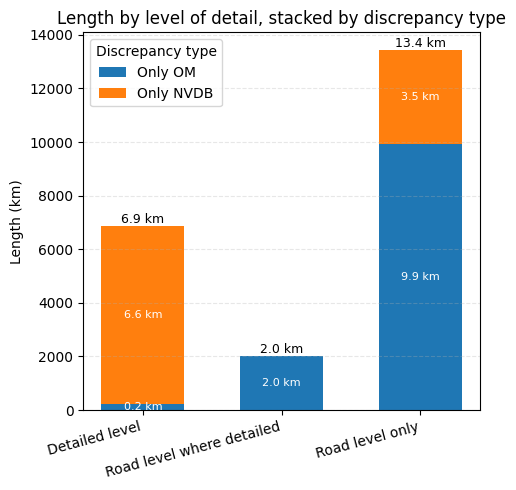

In [29]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Filter to the two datasets we want to compare ---
want = ["Only OM", "Only NVDB"]
df = gdf_tfd[gdf_tfd["dt_comparison"].isin(want)].copy()

# Ensure 'length' is numeric
df["length"] = pd.to_numeric(df["length"], errors="coerce").fillna(0)

# --- Map LODs to the three requested bar groups ---
def map_lod_to_group(lod: str) -> str | None:
    if pd.isna(lod):
        return None
    lod = str(lod)
    if lod in {"Kjørebane", "Kjørefelt"}:
        return "Detailed level"
    elif lod == "Vegtrase":
        return "Road level where detailed"
    elif lod == "Vegtrase og kjørebane":
        return "Road level only"
    else:
        return None

df["bar_group"] = df["lod"].map(map_lod_to_group)
df = df.dropna(subset=["bar_group"])

# --- Aggregate length per bar_group × dt_comparison ---
summary = (
    df.groupby(["bar_group", "dt_comparison"])["length"]
      .sum()
      .reset_index()
)

# --- Pivot to have columns = datasets to stack ---
pivot = summary.pivot(index="bar_group", columns="dt_comparison", values="length").fillna(0)

# Ensure a fixed bar order and column (stack) order
bar_order = [
    "Detailed level",
    "Road level where detailed",
    "Road level only"
]
stack_order = ["Only OM", "Only NVDB"]

# Reindex to guarantee presence/ordering (fill missing with 0)
for col in stack_order:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot.reindex(index=bar_order, fill_value=0)[stack_order]

# --- Plot: stacked bars ---
x = np.arange(len(bar_order))
fig, ax = plt.subplots(figsize=(5, 5))

colors = {
    "Only OM": "#1f77b4",   # blue
    "Only NVDB": "#ff7f0e"  # orange
}

bar_width = 0.6
bottom = np.zeros(len(bar_order))

# Plot each stack and add labels in km
for comp in stack_order:
    values_km = pivot[comp].values / 1000  # convert to km
    bars = ax.bar(
        x,
        pivot[comp].values,
        bottom=bottom,
        label=comp,
        color=colors.get(comp, None),
        width=bar_width
    )
    # Add labels for each segment
    for bar, val in zip(bars, values_km):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + bar.get_height()/2,
                f"{val:.1f} km",
                ha="center", va="center", fontsize=8, color="white"
            )
    bottom += pivot[comp].values

# Annotate totals on top in km
for i, total in enumerate(bottom):
    ax.text(x[i], total, f"{total/1000:.1f} km", ha="center", va="bottom", fontsize=9)

# Labels and styling
ax.set_xticks(x)
ax.set_xticklabels(bar_order, rotation=15, ha="right")
ax.set_ylabel("Length (km)")
ax.set_title("Length by level of detail, stacked by discrepancy type")
ax.legend(title="Discrepancy type")
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


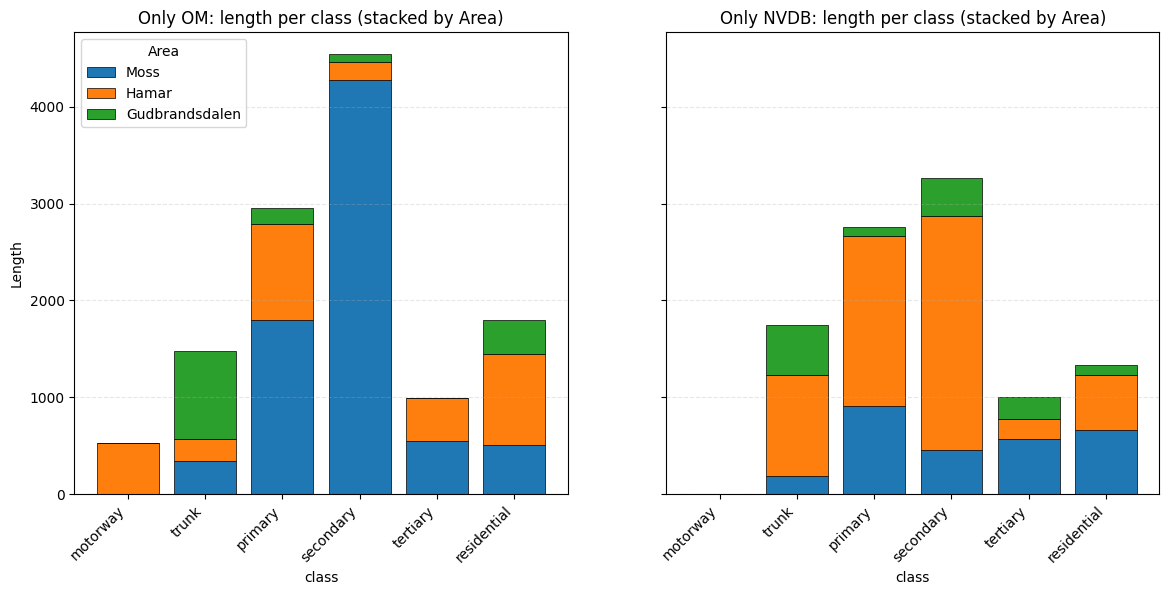

In [30]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------- Parameters ----------------
class_order   = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential']
class_col     = 'class'     # x-axis road class column
area_col      = 'Area'      # stack category
length_col    = 'length'
figsize       = (14, 6)

# Enforce areas and their bottom-to-top stacking order:
# Bottom: Moss → Hamar → Gudbrandsdalen (iterate in this order when stacking)
area_order    = ['Moss', 'Hamar', 'Gudbrandsdalen']

# Sharp, high-contrast colors for Areas (consistent across both plots)
area_to_color = {
    'Moss':            '#1f77b4',  # blue
    'Hamar':           '#ff7f0e',  # orange
    'Gudbrandsdalen':  '#2ca02c',  # green
}

# ---------------- 1) Merge: fill missing 'class' from gdf_allSegements ----------------
# Keep only the two comparisons we want
df = gdf_tfd[gdf_tfd["dt_comparison"].isin(["Only OM", "Only NVDB"])].copy()

# Bring 'class' from reference df using segment_id ↔ id
df = df.merge(
    gdf_allSegements[['id', class_col]],
    how='left',
    left_on='segment_id',
    right_on='id',
    suffixes=('', '_from_segments')
)

# If original 'class' is missing, fill from the reference column
df[class_col] = df[class_col].where(df[class_col].notna(), df[f'{class_col}_from_segments'])

# Clean helper columns
df = df.drop(columns=['id', f'{class_col}_from_segments'])

# Ensure numeric length
df[length_col] = pd.to_numeric(df[length_col], errors='coerce').fillna(0)

# Drop rows still missing class (or set to 'unknown' if you prefer)
df = df[df[class_col].notna()].copy()
# df[class_col] = df[class_col].fillna('unknown')  # alternative

# ---------------- 2) Build pivots for Only OM and Only NVDB (rows=class, cols=Area) ----------------
def build_pivot_for_comp(df_all, comp_value):
    d = df_all[df_all["dt_comparison"] == comp_value].copy()

    # Normalize Area strings in case of stray whitespace/case
    d[area_col] = d[area_col].astype(str).str.strip()

    grouped = (
        d.groupby([class_col, area_col], dropna=False)[length_col]
         .sum()
         .reset_index()
    )

    # rows = class, columns = Area, values = total length
    pivot = grouped.pivot(index=class_col, columns=area_col, values=length_col).fillna(0)

    # Reindex rows to ensure consistent bar order
    pivot = pivot.reindex(index=class_order, fill_value=0)

    # Keep only the specified areas and enforce their stacking order
    pivot = pivot.reindex(columns=area_order, fill_value=0)

    return pivot

pivot_om   = build_pivot_for_comp(df, "Only OM")
pivot_nvdb = build_pivot_for_comp(df, "Only NVDB")

# ---------------- 3) Plot: side-by-side stacked bar charts ----------------
fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

def plot_stacked(ax, pivot, title):
    x = np.arange(len(pivot.index))
    bottom = np.zeros(len(pivot), dtype=float)
    handles = []

    # Iterate in area_order so the first is at the bottom
    for area in area_order:
        heights = pivot[area].values if area in pivot.columns else np.zeros_like(bottom)
        bar = ax.bar(
            x, heights, bottom=bottom,
            color=area_to_color[area], label=str(area),
            edgecolor='black', linewidth=0.5
        )
        handles.append(bar[0])
        bottom += heights

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right")
    ax.set_xlabel(class_col)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    return handles

handles_left = plot_stacked(axes[0], pivot_om,   'Only OM: length per class (stacked by Area)')
_            = plot_stacked(axes[1], pivot_nvdb, 'Only NVDB: length per class (stacked by Area)')

# Shared Y label
axes[0].set_ylabel("Length")

# Legend in the top-left of the LEFT subplot, ordered as Moss → Hamar → Gudbrandsdalen
axes[0].legend(handles_left, area_order, title='Area', loc='upper left', frameon=True)



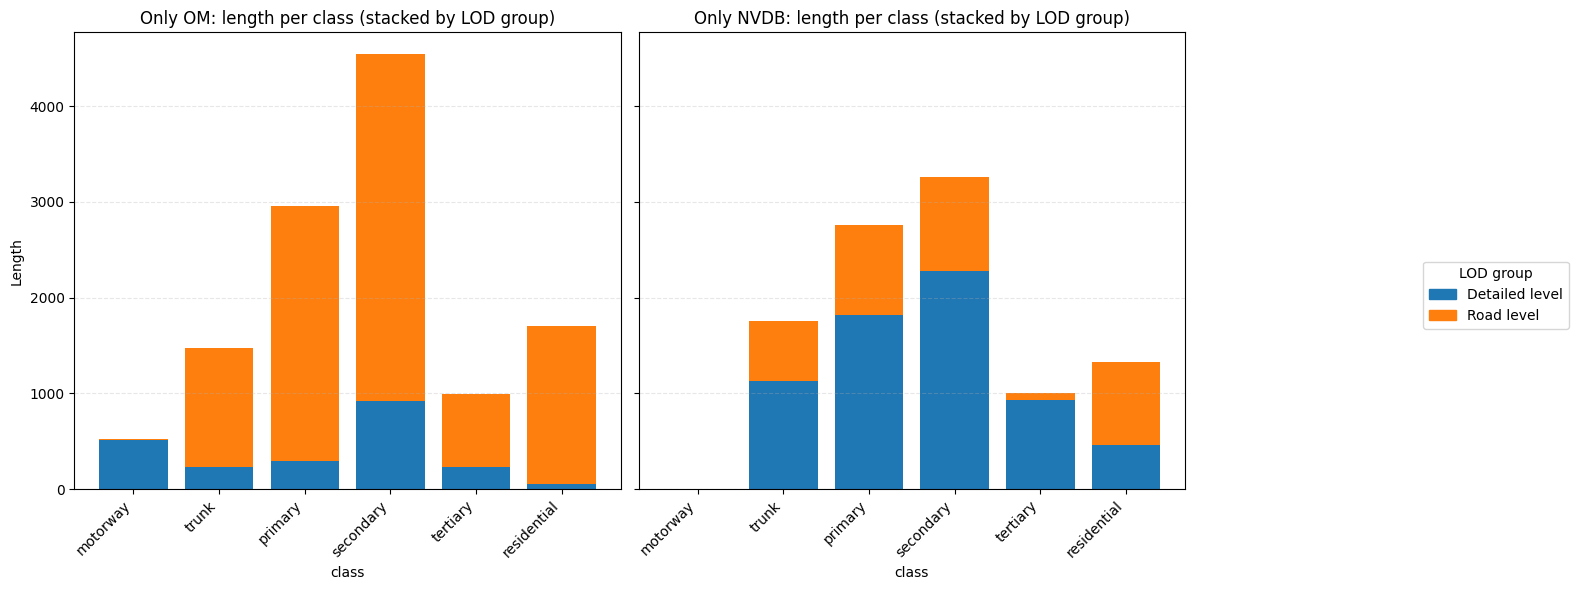

In [31]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------- Parameters ----------------
class_order = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential']
class_col   = 'class'     # x-axis class
lod_col     = 'lod'       # original LOD column
length_col  = 'length'
figsize     = (14, 6)

# LOD grouping (exact mapping you requested)
lod_map = {
    'Kjørebane': 'Detailed level',
    'Vegtrase': 'Detailed level',
    'Vegtrase og kjørebane': 'Road level',
}
lod_group_order = ['Detailed level', 'Road level']  # order in the stacks

# Fixed colors for stable appearance across plots
lod_group_to_color = {
    'Detailed level': '#1f77b4',  # blue
    'Road level':     '#ff7f0e',  # orange
}

# ---------------- 1) Merge: fill missing 'class' from gdf_allSegements ----------------
# Keep only the two comparisons we want
df = gdf_tfd[gdf_tfd["dt_comparison"].isin(["Only OM", "Only NVDB"])].copy()

# Bring 'class' from reference df using segment_id ↔ id
df = df.merge(
    gdf_allSegements[['id', class_col]],
    how='left',
    left_on='segment_id',
    right_on='id',
    suffixes=('', '_from_segments')
)

# If original 'class' is missing, fill from the reference column
df[class_col] = df[class_col].where(df[class_col].notna(), df[f'{class_col}_from_segments'])

# Clean helper columns
df = df.drop(columns=['id', f'{class_col}_from_segments'])

# Ensure numeric length
df[length_col] = pd.to_numeric(df[length_col], errors='coerce').fillna(0)

# Drop rows still missing class (or set to 'unknown' if you prefer)
df = df[df[class_col].notna()].copy()

# ---------------- 2) Map LOD to LOD group and keep only desired groups ----------------
# (You can normalize text before mapping if needed: e.g., df[lod_col] = df[lod_col].str.strip())
df['lod_group'] = df[lod_col].map(lod_map)
df = df[df['lod_group'].isin(lod_group_order)].copy()

# ---------------- 3) Build pivots for Only OM and Only NVDB ----------------
def build_pivot_for_comp(df_all, comp_value):
    d = df_all[df_all["dt_comparison"] == comp_value].copy()

    grouped = (
        d.groupby([class_col, 'lod_group'], dropna=False)[length_col]
         .sum()
         .reset_index()
    )

    # rows = class, columns = lod_group, values = total length
    pivot = grouped.pivot(index=class_col, columns='lod_group', values=length_col).fillna(0)

    # Reindex to ensure consistent bar and stack order
    pivot = pivot.reindex(index=class_order, fill_value=0)
    pivot = pivot.reindex(columns=lod_group_order, fill_value=0)

    return pivot

pivot_om   = build_pivot_for_comp(df, "Only OM")
pivot_nvdb = build_pivot_for_comp(df, "Only NVDB")

# ---------------- 4) Plot: side-by-side stacked bar charts ----------------
fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

def plot_stacked(ax, pivot, title):
    x = np.arange(len(pivot.index))
    bottom = np.zeros(len(pivot), dtype=float)

    for lg in lod_group_order:
        heights = pivot[lg].values if lg in pivot.columns else np.zeros_like(bottom)
        ax.bar(x, heights, bottom=bottom, color=lod_group_to_color[lg], label=lg)
        bottom += heights

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right")
    ax.set_xlabel(class_col)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plot_stacked(axes[0], pivot_om,   'Only OM: length per class (stacked by LOD group)')
plot_stacked(axes[1], pivot_nvdb, 'Only NVDB: length per class (stacked by LOD group)')

# Shared Y label and a single legend outside
axes[0].set_ylabel("Length")
handles = [plt.Rectangle((0,0),1,1, color=lod_group_to_color[lg]) for lg in lod_group_order]
fig.legend(handles, lod_group_order, title='LOD group', loc="center left",
           bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

plt.tight_layout()
plt.subplots_adjust(right=0.85)  # space for legend
plt.show()



# Statistics for Functional Road Class

In [32]:
# Read all GeoJSON files and concatenate into one GeoDataFrame

import geopandas as gpd
import pandas as pd

files = {
    "Hamar": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\om_nvdb_frc.geojson",
    "Moss": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\om_nvdb_frc.geojson",
    "Gudbrandsdalen": r"C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\om_nvdb_frc.geojson",
}

dfs = []

for area, path in files.items():
    print(f"Reading {area} from {path}...") 
    gdf = gpd.read_file(path)
    gdf["Area"] = area
    print(f"  Read {len(gdf)} records." )
    dfs.append(gdf)

# Concatenate all into one GeoDataFrame
gdf_frc = pd.concat(dfs, ignore_index=True)

# Remove one specific segment by its ID
segment_to_remove = '84d1aa20-dcff-425f-911a-fa90c2dd71b2'  # Replace with the actual segment ID to remove      
gdf_frc = gdf_frc[gdf_frc['segment_id'] != segment_to_remove]


Reading Hamar from C:\Data\GitHub\jetgeo\OM2ANY\Data\Hamar\om_nvdb_frc.geojson...
  Read 15911 records.
Reading Moss from C:\Data\GitHub\jetgeo\OM2ANY\Data\Moss\om_nvdb_frc.geojson...
  Read 12482 records.
Reading Gudbrandsdalen from C:\Data\GitHub\jetgeo\OM2ANY\Data\Gudbrandsdalen\om_nvdb_frc.geojson...
  Read 6385 records.


In [33]:

import pandas as pd
import numpy as np

# --- Helper: ensure we have a 'length' column in meters in all GeoDataFrames
def ensure_length_in_meters(gdf, length_col="length", fallback_epsg=25833):
    """
    Returns a copy of gdf with a numeric 'length' column in meters.
    - If length_col exists, it is used (cast to float).
    - Otherwise, compute from geometry. If CRS is geographic (degrees), reproject to fallback_epsg.
    """
    if length_col in gdf.columns:
        return gdf.assign(length=gdf[length_col].astype(float))
    else:
        if getattr(gdf, "crs", None) is None:
            raise ValueError("GeoDataFrame CRS is None. Set an appropriate projected CRS to compute lengths in meters.")
        if gdf.crs.is_geographic:
            gdf = gdf.to_crs(fallback_epsg)
        return gdf.assign(length=gdf.geometry.length.astype(float))

# --- Prepare input GeoDataFrames
gdf_matched_segments = ensure_length_in_meters(gdf_matched_segments)
gdf_sl               = ensure_length_in_meters(gdf_sl)
gdf_frc              = ensure_length_in_meters(gdf_frc)



# Convert to string only for non-null values and strip whitespace
mask = gdf_frc["Vegklasse"].notna() & (gdf_frc["Vegklasse"].astype(str).str.strip() != "")
gdf_frc = gdf_frc[mask]


# --- Summarize lengths per Area
len_matched = gdf_matched_segments.groupby("Area", dropna=False)["length"].sum().rename("length_matched")
len_sl      = gdf_sl.groupby("Area", dropna=False)["length"].sum().rename("length_sl")
len_frc     = gdf_frc.groupby("Area", dropna=False)["length"].sum().rename("length_frc")

# --- Merge all into one comparison table
comparison = pd.concat([len_matched, len_sl, len_frc], axis=1).fillna(0.0)

# --- Metrics: inverse differences and percentages
comparison["diff_sl_vs_matched"]  = comparison["length_matched"] - comparison["length_sl"]
comparison["diff_frc_vs_matched"] = comparison["length_matched"] - comparison["length_frc"]

comparison["pct_sl_vs_matched"] = np.where(
    comparison["length_matched"] == 0, 0.0,
    (comparison["length_sl"] / comparison["length_matched"]) * 100.0
)
comparison["pct_frc_vs_matched"] = np.where(
    comparison["length_matched"] == 0, 0.0,
    (comparison["length_frc"] / comparison["length_matched"]) * 100.0
)

# --- Custom area order
order = ["Moss", "Hamar", "Gudbrandsdalen"]
order_map = {name: i for i, name in enumerate(order)}
sort_key = comparison.index.to_series().map(order_map).fillna(len(order))
comparison = comparison.assign(_sort=sort_key).sort_values("_sort").drop(columns=["_sort"])

# --- TOTAL row
tot_matched = comparison["length_matched"].sum()
tot_sl      = comparison["length_sl"].sum()
tot_frc     = comparison["length_frc"].sum()
tot_diff_sl = comparison["diff_sl_vs_matched"].sum()
tot_diff_frc= comparison["diff_frc_vs_matched"].sum()
tot_pct_sl  = 0.0 if tot_matched == 0 else (tot_sl / tot_matched) * 100.0
tot_pct_frc = 0.0 if tot_matched == 0 else (tot_frc / tot_matched) * 100.0

total_row = pd.Series({
    "length_matched"       : tot_matched,
    "length_sl"            : tot_sl,
    "length_frc"           : tot_frc,
    "diff_sl_vs_matched"   : tot_diff_sl,
    "diff_frc_vs_matched"  : tot_diff_frc,
    "pct_sl_vs_matched"    : tot_pct_sl,
    "pct_frc_vs_matched"   : tot_pct_frc
}, name="TOTAL")

comparison_with_total = pd.concat([comparison, total_row.to_frame().T], axis=0)

# --- Formatting helpers
def fmt_m(val): return f"{int(np.rint(val)):,.0f} m"
def fmt_pct(val): return f"{float(val):.1f} %"

# --- Apply formatting
final = comparison_with_total.copy()
for col in ["length_matched", "length_sl", "length_frc", "diff_sl_vs_matched", "diff_frc_vs_matched"]:
    final[col] = final[col].map(fmt_m)
for col in ["pct_sl_vs_matched", "pct_frc_vs_matched"]:
    final[col] = final[col].map(fmt_pct)

# --- Result
final


,length_matched,length_sl,length_frc,diff_sl_vs_matched,diff_frc_vs_matched,pct_sl_vs_matched,pct_frc_vs_matched
Moss,"499,499 m","498,628 m","498,359 m",871 m,"1,140 m",99.8 %,99.8 %
Hamar,"759,688 m","757,892 m","756,734 m","1,796 m","2,954 m",99.8 %,99.6 %
Gudbrandsdalen,"548,869 m","547,974 m","546,964 m",895 m,"1,905 m",99.8 %,99.7 %
TOTAL,"1,808,055 m","1,804,493 m","1,802,057 m","3,562 m","5,998 m",99.8 %,99.7 %


C:\Users\JETKNU\AppData\Local\Temp\ipykernel_33684\3520461862.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{y/1000:.1f} km' for y in ax.get_yticks()])


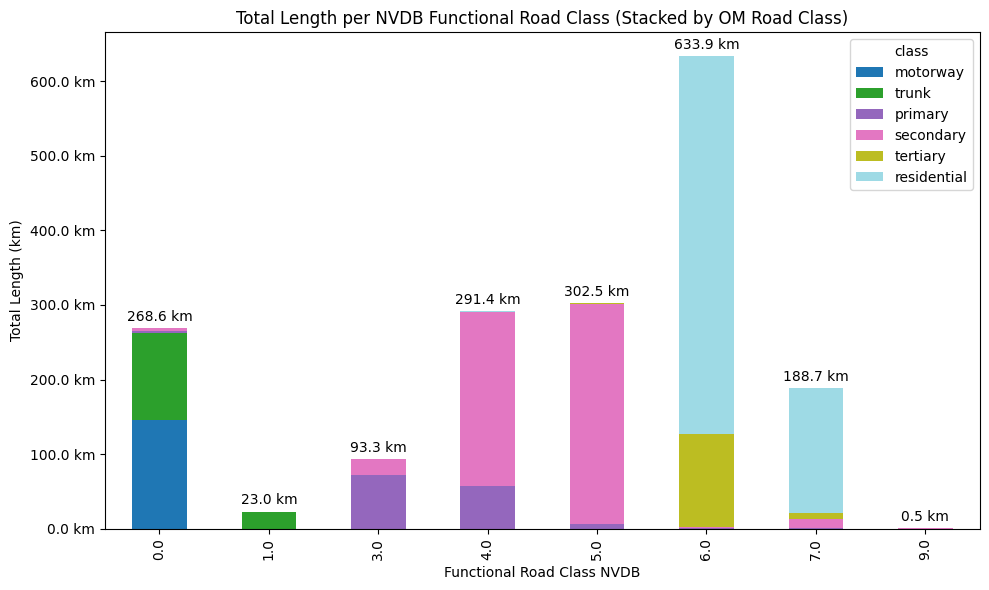

In [34]:
# Generate diagrams with comparision of functional road class and OM class
class_order = ['motorway','trunk','primary','secondary', 'tertiary', 'residential']
gdf_frc['lenght'] = gdf_frc.geometry.length
grouped = gdf_frc.groupby(['Vegklasse', 'class'])['lenght'].sum().unstack(fill_value=0).sort_index()
grouped = grouped.reindex(columns=class_order, fill_value=0)


fig, ax = plt.subplots(figsize=(10, 6))
grouped.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_yticklabels([f'{y/1000:.1f} km' for y in ax.get_yticks()])

for idx, total_m in enumerate(grouped.sum(axis=1)):
    total_km = total_m / 1000
    ax.annotate(f'{total_km:.1f} km',
                xy=(idx, total_m),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.xlabel('Functional Road Class NVDB')
plt.ylabel('Total Length (km)')
plt.title('Total Length per NVDB Functional Road Class (Stacked by OM Road Class)')
plt.tight_layout()
plt.show()
